# The prediction shift phenomenon on ResNet-18, ViT-B/16 and Swin-S

PSBD (Prediction Shift Backdoor Detection, Li et al., arXiv 2406.05826) detects backdoor samples by switching dropout on at inference and watching how much a prediction's confidence falls. The authors justify the method with 4 observations, and they make every one of them on ResNet-18 (plus VGG16-bn in 1 appendix figure). This repository adapts PSBD to 2 vision transformers (ViT-B/16 and Swin-S). Its best detector PSBD-TM perturbs the network in a way the paper never tried: it zeroes whole tokens at the input of every attention LayerNorm. A detector can work while the story told about it is wrong. This notebook asks, for each observation the paper makes, whether it can be seen on our own ResNet-18 checkpoints, and then whether the same measurement shows it on ViT-B/16 and Swin-S.

The notebook is written for a reader who knows backdoor attacks but has not read this repository. It reads cached JSON only and runs in under a minute on a login node. Every number comes from `experiments/prediction_shift_phenomenon/measure.py`, whose `README.md` states the same method with its formulas and deviations. A claim that fails is reported with the same figures as one that holds.

A few terms recur. A **poisoned model** was trained on data where some images carry the attacker's **trigger** and are labeled with the **target class**. A **benign model** was trained without poison. A **triggered image** is a clean test image with the trigger applied, and a **captured** triggered image is a triggered image the unperturbed model actually sends to the target. **PSBD-RD** is our version of the paper's own site, an `nn.Dropout` after every residual add (8 sites on ResNet-18, 24 on ViT-B/16, 48 on Swin-S). **PSBD-TM** is `token_mask` before every attention LayerNorm, which exists only on the transformers. The **rate p** is the drop probability, **k = 3** is the number of perturbed forward passes, and the **adaptive rate** is the smallest swept p at which 80% of clean validation predictions change (`defenses.decision.select_rate_adaptively`), the rate PSBD deploys.

## Map of the steps

| step | the paper's claim | their figure | our figure | data |
|---|---|---|---|---|
| 0 | none, the models and the sanity gates | none | 2 tables | `cached/`, `sanity/` |
| 1 | the clean shift ratio rises and saturates while the backdoor one stays near 0 | Fig. 3 top, A3 to A5 | shift ratio curves, triggered shift ratio per model | stage-1 caches, all panel models |
| 2 | shifted clean predictions land on the target, and on a benign model on 1 dominant class | Fig. 3 bottom, A3 to A5 | landing histograms, target share per model | stage-1 caches, all panel models |
| 3 | top-layer features of a clean image and its triggered twin become almost identical under dropout | Fig. 4, A6, A7 | 64 channel maps, pair and control similarity | GPU forward passes, 1 model per attack family |
| 4 | MC-Dropout standard deviation separates BadNets and fails on WaNet and Adaptive-Blend | Fig. 2, A1 | standard deviation curves, AUROC against PSU | stage-1 caches, all panel models |
| 5 | none, whether the best residual placement works through neuron bias | none | 3 strips, 2 tables | stage-1 caches and 12 GPU readings |
| 6 | none, the verdicts | none | 1 table | `summary.json` |

Each step quotes the claim, says how the paper showed it, says how we measure it and with which functions, draws ResNet-18 next to ViT-B/16 and Swin-S, and closes with what the figure shows, what it does not show and the next question it raises.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle

from defenses.decision import (
    ADAPTIVE_SHIFT_TARGET,
    PUBLISHED_PLACEMENT,
    RECOMMENDED_PLACEMENT,
)
from experiments.prediction_shift_phenomenon.measure import (
    ALMOST_ALL_ON_TARGET,
    BEST_RESIDUAL_PLACEMENT,
    IDENTICAL_COSINE,
    NEAR_ZERO_SHIFT,
    PAPER_FEATURE_RATE,
    PAPER_MATCH_TOLERANCE,
    PLACEMENT_LABELS,
    STD_LOSES_BY,
)
from scripts.paper._common import OKABE_ITO

In [3]:
import scripts.paper._style  # noqa: F401  the figure style every paper figure uses

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline

In [4]:
OUTPUT = Path("results/_experiments/prediction_shift_phenomenon")


def read_records(name):
    records = {
        path.stem: json.loads(path.read_text())
        for path in sorted((OUTPUT / name).glob("*.json"))
    }
    return records


cached = read_records("cached")
features = read_records("features")
feature_maps = read_records("feature_maps")
sanity = read_records("sanity")
summary = json.loads((OUTPUT / "summary.json").read_text())
# The CIFAR-10 ResNet-18 smoke run is not a successful backdoor (clean accuracy
# 0.54), so it is kept out of every figure and verdict here.
all_rows = pd.DataFrame(summary["cached_rows"])
rows = all_rows[~all_rows["reference_only"]]
all_feature_rows = pd.DataFrame(summary["feature_rows"])
feature_rows = all_feature_rows[~all_feature_rows["reference_only"]]

ARCHITECTURES = ("resnet18", "vit", "swin")
ARCHITECTURE_LABELS = {"resnet18": "ResNet-18", "vit": "ViT-B/16", "swin": "Swin-S"}
PLACEMENTS = (PUBLISHED_PLACEMENT, RECOMMENDED_PLACEMENT)
CATEGORY_ORDER = (
    "patch",
    "blend",
    "warp",
    "quantization",
    "adaptive blend",
)
CATEGORY_COLORS = dict(zip(CATEGORY_ORDER, OKABE_ITO))
# The 1 cell all 3 architectures share: GTSRB, BadNets, 10% poisoning, target 0.
FIGURE_CELL = {
    "resnet18": "resnet18_gtsrb_badnet_a2o_0_1",
    "vit": "vit_gtsrb_badnet_a2o_0_1",
    "swin": "swin_gtsrb_badnet_a2o_0_1",
}
BENIGN_CELL = {
    architecture: next(
        (
            folder
            for folder in (f"{architecture}_gtsrb_benign", f"{architecture}_cifar100_benign")
            if folder in cached
        ),
        None,
    )
    for architecture in ("vit", "swin")
}
print(
    f"{len(cached)} models with cached curves, {len(features)} with feature readings, "
    f"{len(sanity)} sanity records"
)
print("benign controls drawn next to the GTSRB BadNets cell:", BENIGN_CELL)

146 models with cached curves, 26 with feature readings, 10 sanity records
benign controls drawn next to the GTSRB BadNets cell: {'vit': 'vit_gtsrb_benign', 'swin': 'swin_gtsrb_benign'}


## Step 0, the models

The ResNet-18 checkpoints are the 3 of `experiments/resnet_control/` trained without an evasion penalty: GTSRB BadNets and GTSRB Blend at 10% for 100 epochs, and a CIFAR-10 BadNets smoke run (15 epochs on 20000 images). The smoke run reaches ASR 0.998 but clean accuracy 0.54, far outside the 2-point success bar the transformers are held to, so it is not a successful backdoor: the README shows it on its own reference row and this notebook leaves it out of every figure and verdict, which rest on the 2 GTSRB models. No benign ResNet-18 exists, and this experiment trains nothing, so the benign controls are transformers only. The ViT-B/16 and Swin-S models are the successful backdoors of the paper: the attack success rate clears 0.85, the model neither diverged nor maps its TaCT source class to the target, and its clean accuracy is within 2 points of its benign reference (`successful_2pt`, `scripts.paper._common.clearing_cells` and `scripts.paper.tab_swin.swin_cells`). A failed attack is left out even when a whole family disappears with it, since a model that is not a backdoor cannot show a backdoor phenomenon. That leaves 56 ViT-B/16 (on 2026-09-30) and 65 Swin-S models, and Swin-S adds Adaptive-Blend models the ViT panel lacks. SIG models are left out everywhere: the SIG checkpoints learned trigger amplitude 0.1 and `attacks/sig.py` now builds 0.157 (`docs/audits/2026-09-29-experiment-audit.md`), so a fresh forward pass would score a trigger the model never saw.

The table counts models per trigger family, 1 row per family, for PSBD-RD. The families group attacks by the shape of their trigger: patch (BadNets and TaCT), blend (Blend and low-frequency LF), warp (WaNet), quantization (BPP) and adaptive blend.

In [5]:
panel = (
    rows[rows["placement"] == PUBLISHED_PLACEMENT]
    .assign(kind=lambda frame: np.where(frame["benign"], "benign", frame["category"]))
    .pivot_table(index="kind", columns="architecture", values="folder", aggfunc="count")
    .reindex(columns=list(ARCHITECTURES))
    .fillna(0)
    .astype(int)
)
panel.loc["total"] = panel.sum()
panel

architecture,resnet18,vit,swin
kind,,,
adaptive blend,0,0,7
benign,0,4,3
blend,1,24,24
clean label patch,0,1,0
patch,1,16,14
quantization,0,12,12
warp,0,3,8
total,2,60,68


## Sanity gates

Before any number was trusted, `experiments/prediction_shift_phenomenon/sanity.py` checked 5 things on GTSRB BadNets 10% on all 3 architectures, and after the audit on 3 more cells (ResNet-18 Blend, ViT CIFAR-100 Blend, Swin Tiny BPP). Gate 1 asks whether the forward path the claim 3 measurement uses reproduces the clean accuracy and attack success rate recorded at training time, within 0.01. Gate 2 asks whether the perturbation path gives the shift ratio the stage-1 cache holds at the same rates, within 0.03 (about 4.5 binomial standard errors for 2000 images and 3 passes), and for ResNet-18 whether 1 probe sits after each of the 8 residual adds, before the ReLU, which is where Li et al. put it ("dropout layers are applied after each residual connection in the residual basic block, before the activation function"). Gate 3 asks whether the triggered set is the evaluation set `CLAUDE.md` prescribes and whether each clean image and its triggered twin are the same test image. Gate 4 asks whether the model is in eval mode with every model-owned dropout at 0, whether every hook comes off and whether a new seed draws a new mask. A float32 rerun of gate 2 on ViT checks that bfloat16 changes nothing.

The first version of gate 4 compared predictions across seeds and failed on Swin under PSBD-TM at p = 0.5. The reason is benign: at that rate every pass sends every image to 1 class whatever the mask, so predictions agree across seeds while the masks differ. The gate now compares final-layer features, which differ whenever the mask does. The `_state` records hold that rerun. Every claim 3 run also compares its own unperturbed predictions with the cache and stops below 0.98 agreement.

In [6]:
sanity_rows = []
for name, record in sanity.items():
    shift = record.get("gate_2_shift_ratio")
    if shift:
        largest_gap = max(row["gap"] for row in shift["rows"])
        sanity_rows.append(
            {
                "record": name,
                "gate": "2 shift ratio vs cache",
                "reading": f"largest gap {largest_gap:.4f} over {len(shift['rows'])} rates, "
                f"unperturbed argmax agrees with cache on {shift['baseline_prediction_agreement']:.3f}",
                "passes": shift["passes"],
            }
        )
        if "probe_sites" in shift:
            sites = shift["probe_sites"]
            sanity_rows.append(
                {
                    "record": name,
                    "gate": "2 ResNet probe sites",
                    "reading": f"{sites['probes']} probes on {sites['basic_blocks']} basic blocks, "
                    f"{sites['wrapped']} block forwards wrapped",
                    "passes": sites["probes"] == sites["basic_blocks"],
                }
            )
    metrics = record.get("gate_1_metrics")
    if metrics:
        sanity_rows.append(
            {
                "record": name,
                "gate": "1 accuracy and ASR",
                "reading": f"clean {metrics['clean_accuracy']:.4f} vs {metrics['recorded']['clean_accuracy']:.4f}, "
                f"ASR {metrics['attack_success_rate']:.4f} vs {metrics['recorded']['asr']:.4f} "
                f"({metrics['recorded']['source']})",
                "passes": metrics["passes"],
            }
        )
    pairs = record.get("gate_3_pairs")
    if pairs:
        sanity_rows.append(
            {
                "record": name,
                "gate": "3 pairs",
                "reading": f"{pairs['backdoor_set_class']}, {pairs['pairs']} pairs, labels "
                f"{pairs['backdoor_labels']}, {pairs['changed_pixel_share_mean']:.4f} of pixels changed",
                "passes": pairs["passes"],
            }
        )
    state = record.get("gate_4_state")
    if state:
        resampling = ", ".join(
            f"{PLACEMENT_LABELS[placement]} same seed identical {reading['same_seed_identical']}, "
            f"new seed changes {reading['new_seed_differs_share']:.2f} of feature entries"
            for placement, reading in state["resampling"].items()
        )
        sanity_rows.append(
            {
                "record": name,
                "gate": "4 model state",
                "reading": f"{len(state['modules_in_training_mode'])} modules in training mode, "
                f"hooks {state['hooks_before']} before and {state['hooks_after']} after, {resampling}",
                "passes": state["passes"],
            }
        )
pd.set_option("display.max_colwidth", 200)
pd.DataFrame(sanity_rows)

,record,gate,reading,passes
0,resnet18_gtsrb_badnet_a2o_0_1,2 shift ratio vs cache,"largest gap 0.0040 over 3 rates, unperturbed argmax agrees with cache on 1.000",True
1,resnet18_gtsrb_badnet_a2o_0_1,2 ResNet probe sites,"8 probes on 8 basic blocks, 8 block forwards wrapped",True
2,resnet18_gtsrb_badnet_a2o_0_1,1 accuracy and ASR,"clean 0.9761 vs 0.9761, ASR 1.0000 vs 1.0000 (args.json)",True
3,resnet18_gtsrb_badnet_a2o_0_1,3 pairs,"AttackSuccessSet, 10578 pairs, labels [0], 0.0086 of pixels changed",True
4,resnet18_gtsrb_badnet_a2o_0_1,4 model state,"0 modules in training mode, hooks 0 before and 0 after, PSBD-RD same seed identical True, new seed changes 0.57 of feature entries",True
5,resnet18_gtsrb_badnet_a2o_0_1_state,4 model state,"0 modules in training mode, hooks 0 before and 0 after, PSBD-RD same seed identical True, new seed changes 0.63 of feature entries",True
6,resnet18_gtsrb_blend_0_1,2 shift ratio vs cache,"largest gap 0.0068 over 3 rates, unperturbed argmax agrees with cache on 1.000",True
7,resnet18_gtsrb_blend_0_1,2 ResNet probe sites,"8 probes on 8 basic blocks, 8 block forwards wrapped",True
8,resnet18_gtsrb_blend_0_1,1 accuracy and ASR,"clean 0.9743 vs 0.9743, ASR 1.0000 vs 1.0000 (args.json)",True
9,resnet18_gtsrb_blend_0_1,3 pairs,"AttackSuccessSet, 10578 pairs, labels [0], 1.0000 of pixels changed",True


## Step 1, the shift ratio curve

**In plain words.** Switch dropout on and count how often the model changes its answer. For clean images that count should climb as dropout gets stronger, until almost every answer changes. For triggered images on a poisoned model the answer should hardly ever change, because the trigger is a strong, simple shortcut the model keeps using. On a benign model triggered images should behave like clean ones. The isolating test changes 1 thing, the dropout rate, holds the model and images fixed and uses the benign model and the clean images as controls.

**The claim.** "In the BadNets and WaNet scenarios, we observe that the shift ratio curve for clean data still follows an increasing trend as p increases, eventually stabilizing. However, when p reaches a certain special value, the sigma for backdoor data approaches 0, while the sigma for clean data reaches a relatively high value (around 0.8)." And for the benign model, "both clean and backdoor training data exhibit similar shift ratio trends". (Li et al., Section 4.2, Fig. 3 top row, with more attacks in Fig. A3, Tiny ImageNet in Fig. A4 and VGG16-bn in Fig. A5.)

**How they showed it.** Fig. 3 plots the shift ratio against the dropout rate from 0.1 to 0.9 for CIFAR-10 ResNet-18 models poisoned at 10%, with 1 curve each for clean training, backdoor training and clean validation images. On the BadNets model the clean and validation curves rise from about 0 to about 0.9 by p = 0.6 and stay there. The backdoor curve rises to about 0.25 near p = 0.37 and falls back to about 0 by p = 0.6, and the adaptively chosen p = 0.7 sits in that trough. On the benign model all curves lie on top of each other.

**How we measure it.** The shift ratio is the paper's Eq. (PS definition),

$$\sigma(\mathcal{D}) = \frac{1}{k|\mathcal{D}|}\sum_{\mathbf{x}\in\mathcal{D}}\sum_{i=1}^{k}\mathbb{I}\left(\mathcal{Y}(\mathbf{x};\boldsymbol\theta)\neq\mathcal{Y}(\mathbf{x};\boldsymbol\theta'_i)\right),$$

| symbol | meaning |
|---|---|
| $\mathcal{D}$ | 1 split: 2000 clean validation images, the clean analysis images, or the captured triggered images |
| $\mathcal{Y}(\mathbf{x};\boldsymbol\theta)$ | the unperturbed predicted class |
| $\mathcal{Y}(\mathbf{x};\boldsymbol\theta'_i)$ | the predicted class on perturbed pass i |
| $k$ | 3 passes |

computed by `defenses.scores.shift_ratio` inside `measure.measure_rate` from the tensors `cli.sweep` cached for every model, at every swept rate (0.005 to 0.9 for PSBD-RD, 0.05 to 0.9 for PSBD-TM). Our splits are test images, where the paper uses the poisoned training set, so our backdoor curve keeps only the triggered test images the model sends to the target, the analogue of fitted poison. The verdict per model reads the triggered $\sigma$ at the adaptive rate. It holds at 0.1 or below, it is partial when another rate with a saturated clean curve reaches 0.1 and the adaptive rule missed it, and it fails otherwise. On a benign model it holds when the clean and triggered curves differ by at most 0.1 on average.

The first figure puts the 1 cell all 3 architectures share, GTSRB BadNets at 10%, side by side: ResNet-18 on the left, ViT-B/16 in the middle, Swin-S on the right, PSBD-RD on top and PSBD-TM below. The x axis is the rate on a log scale, because on a transformer the dropout sites compound and PSBD-RD saturates near p = 0.1. The y axis is the shift ratio. The purple dash-dot line is the adaptive rate, the grey line the 0.8 target. The dotted black and grey curves are a benign model of the same architecture probed with the same BadNets trigger.

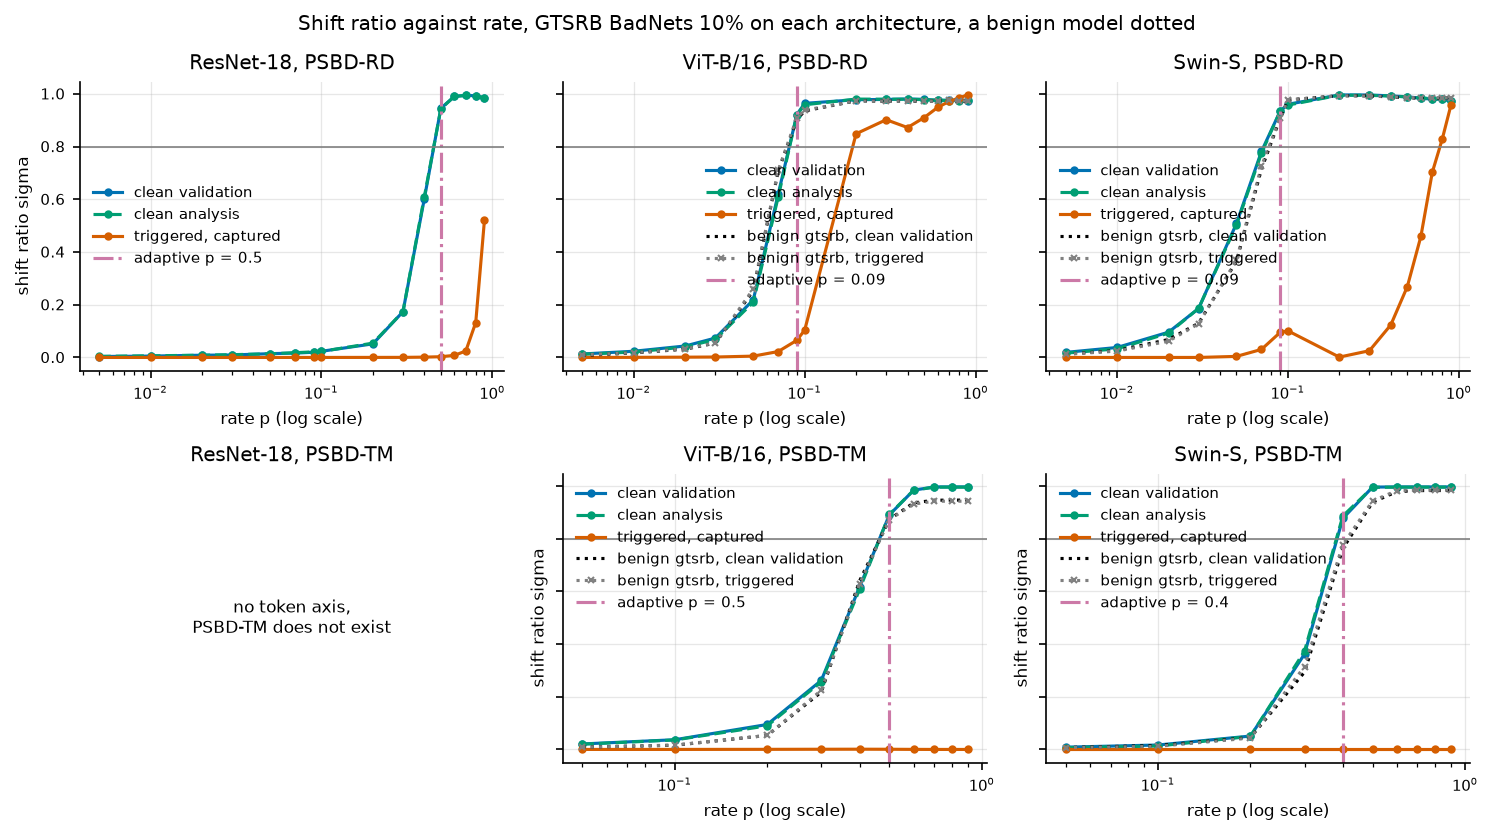

In [7]:
SPLIT_STYLES = {
    "validation": ("clean validation", OKABE_ITO[0], "-"),
    "clean": ("clean analysis", OKABE_ITO[2], "--"),
    "backdoor": ("triggered, captured", OKABE_ITO[1], "-"),
}


def rate_series(record, placement, field, key):
    block = record["placements"][placement]
    rates = [row["rate"] for row in block["per_rate"]]
    values = [row[field][key] for row in block["per_rate"]]
    return rates, values


figure, axes = plt.subplots(2, 3, figsize=(10, 5.6), sharey=True)
for column, architecture in enumerate(ARCHITECTURES):
    record = cached[FIGURE_CELL[architecture]]
    benign_folder = BENIGN_CELL.get(architecture)
    for row_index, placement in enumerate(PLACEMENTS):
        axis = axes[row_index, column]
        if placement not in record["placements"]:
            axis.text(0.5, 0.5, "no token axis,\nPSBD-TM does not exist", ha="center", va="center", transform=axis.transAxes)
            axis.set_title(f"{ARCHITECTURE_LABELS[architecture]}, {PLACEMENT_LABELS[placement]}")
            axis.set_axis_off()
            continue
        for split, (label, color, style) in SPLIT_STYLES.items():
            rates, values = rate_series(record, placement, "sigma", split)
            axis.plot(rates, values, style, color=color, marker="o", markersize=3, label=label)
        if benign_folder and placement in cached[benign_folder]["placements"]:
            rates, values = rate_series(cached[benign_folder], placement, "sigma", "validation")
            benign_dataset = cached[benign_folder]["dataset"]
            axis.plot(rates, values, ":", color="black", label=f"benign {benign_dataset}, clean validation")
            rates, values = rate_series(cached[benign_folder], placement, "sigma", "backdoor")
            axis.plot(rates, values, ":", color="grey", marker="x", markersize=3, label=f"benign {benign_dataset}, triggered")
        adaptive = record["placements"][placement]["adaptive_rate"]
        axis.axvline(adaptive, color=OKABE_ITO[3], linestyle="-.", label=f"adaptive p = {adaptive:g}")
        axis.axhline(ADAPTIVE_SHIFT_TARGET, color="grey", linewidth=0.8)
        axis.set_xscale("log")
        axis.set_title(f"{ARCHITECTURE_LABELS[architecture]}, {PLACEMENT_LABELS[placement]}")
        axis.set_xlabel("rate p (log scale)")
        if column == 0 or row_index == 1:
            axis.set_ylabel("shift ratio sigma")
        axis.legend()
figure.suptitle("Shift ratio against rate, GTSRB BadNets 10% on each architecture, a benign model dotted")
figure.tight_layout()
plt.show()

**What the curves show.** ResNet-18 reproduces the paper's shape. Its clean curves rise to 0.95 at the adaptive p = 0.5 and saturate near 0.99, while the triggered curve stays at 0.003 up to p = 0.6 and only lifts at p = 0.8 and above. ViT-B/16 and Swin-S under PSBD-RD saturate their clean curves 5 times earlier, near p = 0.09, and the triggered curve follows about 1 step later: at the adaptive p it reads 0.065 on ViT and 0.095 on Swin, and at p = 0.2 it is 0.85 on ViT. The window in which clean predictions have all moved and triggered ones have not is narrow on transformers under the paper's site, and the adaptive rule happens to land in it on this cell. PSBD-TM behaves the way the paper's figure does. The clean curves rise through 0.3 to 0.5 and saturate, and the triggered curve stays at 0.000 at every rate up to 0.9 on both transformers. The benign curves lie on the clean curves, as the paper's benign panel does.

The strip plot below reads the triggered $\sigma$ at the adaptive rate for every panel model, 1 dot per model, grouped by trigger family, with benign models as black crosses. The dashed line is the 0.1 threshold. The tables after it count the verdicts per architecture and placement and give the median triggered $\sigma$ per attack.

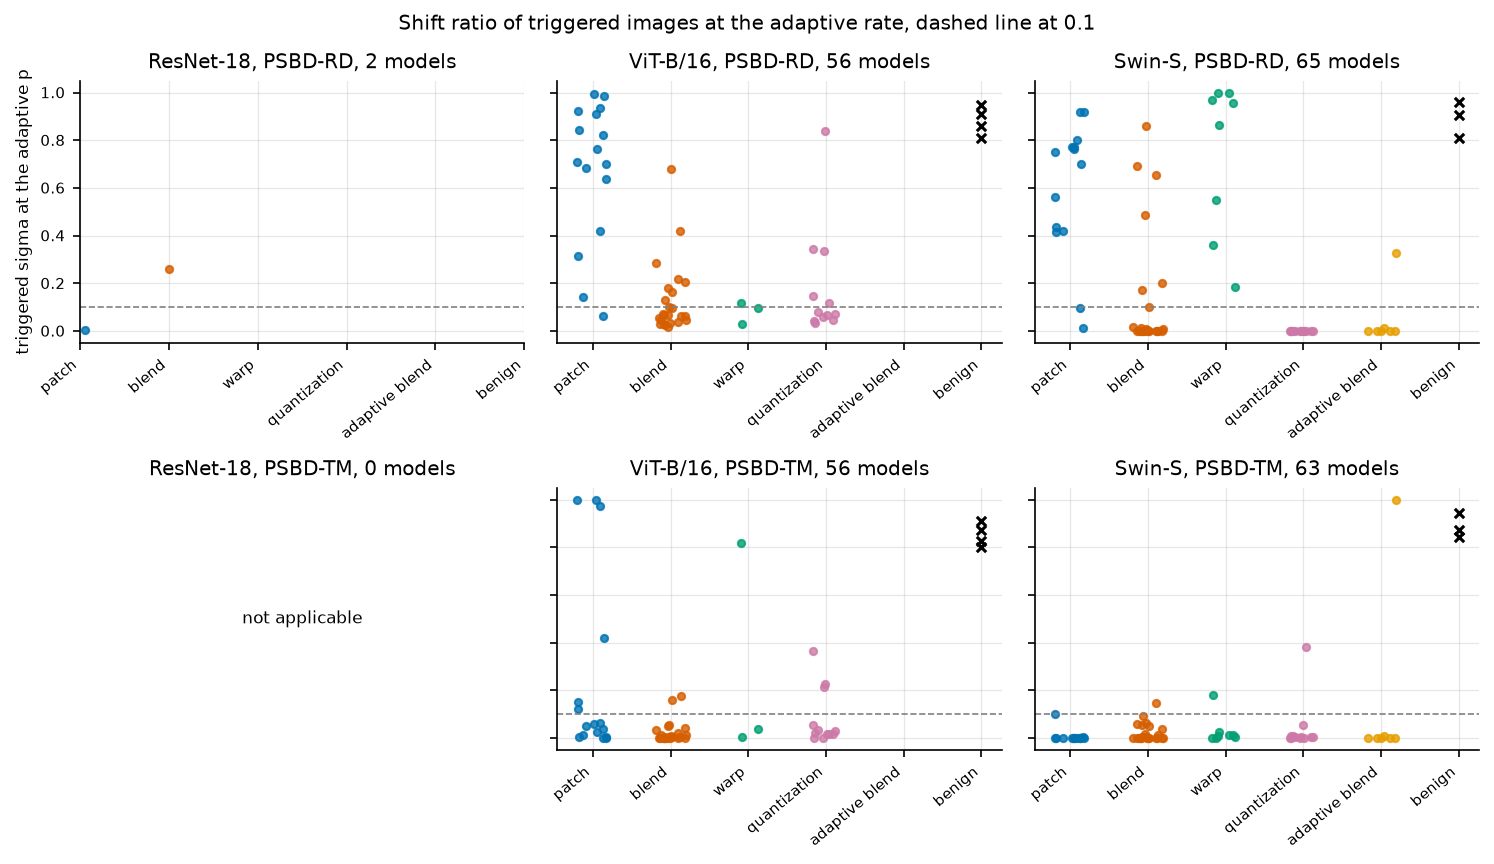

In [8]:
def strip_plot(axis, frame, value, threshold=None, benign_value=None):
    for position, category in enumerate(CATEGORY_ORDER):
        values = frame.loc[(frame["category"] == category) & ~frame["benign"], value].dropna()
        jitter = np.random.default_rng(position).uniform(-0.2, 0.2, len(values))
        axis.scatter(position + jitter, values, s=12, color=CATEGORY_COLORS[category], alpha=0.8)
    benign = frame.loc[frame["benign"], benign_value or value].dropna()
    axis.scatter(np.full(len(benign), len(CATEGORY_ORDER)), benign, marker="x", color="black", s=20)
    axis.set_xticks(range(len(CATEGORY_ORDER) + 1))
    axis.set_xticklabels([*CATEGORY_ORDER, "benign"], rotation=40, ha="right")
    if threshold is not None:
        axis.axhline(threshold, color="grey", linestyle="--", linewidth=0.8)


figure, axes = plt.subplots(2, 3, figsize=(10, 5.8), sharey=True)
for column, architecture in enumerate(ARCHITECTURES):
    for row_index, placement in enumerate(PLACEMENTS):
        axis = axes[row_index, column]
        frame = rows[(rows["architecture"] == architecture) & (rows["placement"] == placement)]
        axis.set_title(f"{ARCHITECTURE_LABELS[architecture]}, {PLACEMENT_LABELS[placement]}, {int((~frame['benign']).sum())} models")
        if frame.empty:
            axis.text(0.5, 0.5, "not applicable", ha="center", va="center", transform=axis.transAxes)
            axis.set_axis_off()
            continue
        strip_plot(axis, frame, "sigma_backdoor", threshold=NEAR_ZERO_SHIFT)
        if column == 0:
            axis.set_ylabel("triggered sigma at the adaptive p")
figure.suptitle(f"Shift ratio of triggered images at the adaptive rate, dashed line at {NEAR_ZERO_SHIFT}")
figure.tight_layout()
plt.show()

In [9]:
def verdict_counts(frame, claim):
    counts = frame[claim].value_counts()
    text = ", ".join(f"{verdict} {count}" for verdict, count in counts.items())
    return text


claim_1_rows = []
for architecture in ARCHITECTURES:
    for placement in PLACEMENTS:
        frame = rows[(rows["architecture"] == architecture) & (rows["placement"] == placement)]
        if frame.empty:
            continue
        poisoned, benign = frame[~frame["benign"]], frame[frame["benign"]]
        claim_1_rows.append(
            {
                "architecture": ARCHITECTURE_LABELS[architecture],
                "placement": PLACEMENT_LABELS[placement],
                "poisoned models": len(poisoned),
                "verdicts": verdict_counts(poisoned, "claim_1"),
                "median clean validation sigma": poisoned["sigma_validation"].median(),
                "median triggered sigma": poisoned["sigma_backdoor"].median(),
                "benign models": len(benign),
                "benign mean curve gap": benign["mean_curve_gap"].max() if len(benign) else np.nan,
            }
        )
pd.DataFrame(claim_1_rows).round(3)

,architecture,placement,poisoned models,verdicts,median clean validation sigma,median triggered sigma,benign models,benign mean curve gap
0,ResNet-18,PSBD-RD,2,"holds 1, fails 1",0.920,0.131,0,NaN
1,ViT-B/16,PSBD-RD,56,"fails 30, holds 26",0.863,0.125,4,0.010
2,ViT-B/16,PSBD-TM,56,"holds 44, fails 12",0.872,0.018,4,0.011
3,Swin-S,PSBD-RD,65,"holds 37, fails 15, partial 13",0.859,0.011,3,0.012
4,Swin-S,PSBD-TM,63,"holds 58, fails 5",0.868,0.002,3,0.010


In [10]:
by_attack = (
    rows[~rows["benign"]]
    .groupby(["architecture", "placement", "attack"])
    .agg(models=("folder", "count"), holds=("claim_1", lambda s: int((s == "holds").sum())), median_triggered_sigma=("sigma_backdoor", "median"))
    .round(3)
    .reset_index()
)
by_attack["placement"] = by_attack["placement"].map(PLACEMENT_LABELS)
by_attack.pivot_table(index="attack", columns=["architecture", "placement"], values="median_triggered_sigma").round(2)

architecture   resnet18    swin             vit          \
placement       PSBD-RD PSBD-RD PSBD-TM PSBD-RD PSBD-TM   
attack                                                    
adaptive_blend      NaN    0.00    0.00     NaN     NaN   
badnet_a2o         0.00    0.63    0.00    0.69    0.03   
blend              0.26    0.00    0.00    0.06    0.01   
bpp                 NaN    0.00    0.00    0.08    0.02   
lc                  NaN     NaN     NaN    0.97    0.02   
lf                  NaN    0.14    0.01    0.12    0.00   
tact                NaN    0.78     NaN    0.92    0.99   
wanet               NaN    0.91    0.01    0.10    0.04   

architecture                                 
placement      best residual, blocks 5 to 8  
attack                                       
adaptive_blend                          NaN  
badnet_a2o                             0.22  
blend                                  0.02  
bpp                                    0.08  
lc                                     0.75  
lf                                     0.03  
tact                                   0.92  
wanet                                  0.01

**Verdict for claim 1.**

**Claim 1 on ResNet-18 is partial**, 1 of 2 models. GTSRB BadNets keeps the triggered shift ratio at 0.003 at its adaptive rate 0.5 while the clean curve reaches 0.95, the shape of the paper's Fig. 3. GTSRB Blend fails: its triggered ratio is 0.26 at every rate where the clean curve has saturated. The CIFAR-10 smoke run, reference only, shows the paper's shape too (0.022 against 0.87).

**Claim 1 on ViT-B/16 is partial under PSBD-RD and holds under PSBD-TM.** Under PSBD-RD the clean curves saturate near p = 0.09 and the triggered curves follow about 1 grid step later, so the window the paper describes is narrow, and 30 of 56 models miss it (median triggered ratio 0.12). The failures are BadNets on 11 of 12 models (median 0.69), TaCT on 4 of 4 (0.92), the LC model (0.97) and 14 Blend, LF, BPP and WaNet models between 0.12 and 0.84, most of them on CIFAR-10 and CIFAR-100. Under PSBD-TM 44 of 56 hold with a median of 0.018. The 12 failures are the 4 trigger-conditional TaCT models (1.00, 1.00, 0.97 and 0.42, the first 2 `vit_cifar10_tact_0_01` and `vit_gtsrb_tact_0_01_cos`), 7 CIFAR-10, GTSRB and Tiny models of BadNets, Blend and BPP at 0.12 to 0.36, and `vit_cifar10_wanet_0_1` at 0.82.

**Claim 1 on Swin-S is partial under PSBD-RD and holds under PSBD-TM.** Under PSBD-RD 37 of 65 hold, 13 are partial and 15 fail. Every Swin WaNet model is partial: some rate with a saturated clean curve brings its triggered ratio to 0, and the adaptive rule picks a rate where the median is still 0.91. BadNets fails or is partial on 10 of 12 and TaCT fails on 2 of 2. Under PSBD-TM 58 of 63 hold with a median of 0.002.

**The benign half of claim 1 holds** on all 7 benign transformers. The mean gap between the clean and the triggered curve is at most 0.012.

**Why claim 1 fails where it fails, a hypothesis here.** The isolating test (masking only the trigger's tokens, with random tokens as the control) is `experiments/why_token_masking_works/`, not this experiment. The failures follow trigger shape and site, not dataset. Dropout on the residual stream fails on patch triggers on both transformers, and that experiment found the few tokens that carry a patch trigger are corrupted by stream dropout in every block, so the triggered prediction breaks as easily as a clean one, while a token masked at the attention input keeps its entry in the stream. On `vit_cifar10_tact_0_05` under PSBD-TM the triggered predictions move with the clean ones (0.97 of passes), yet PSU still separates the 2 sets (AUROC 0.97), because the target keeps a mean probability of 0.05 under the perturbation while a clean image's own class keeps 0.007. On such models the argmax shift the paper describes and the confidence drop PSBD scores come apart.

**What this does not show.** The curves use clean test images where the paper uses the poisoned training set, so our clean training curve is absent. A captured triggered test image is the closest analogue of fitted poison, but it was never trained on. The ResNet-18 evidence is 2 GTSRB models, and there is no benign ResNet-18.

**Next question.** A shifted prediction has to go somewhere. The paper says it goes to the target, which is claim 2.

## Step 2, where the shifted predictions land

**In plain words.** When a clean image's answer does change under dropout, the paper says it changes to the attacker's target class, because the backdoor left the network leaning toward that class. The isolating test holds the rate at the one PSBD deploys and reads which class the changed answers go to. The control is a benign model, which has no target to lean toward.

**The claim.** "The most important thing is, among the samples experiencing PS, almost all clean data shifts to the target class y_t (class 0 in our experiments)", and for the benign model "about 60% of clean training data that experience Prediction Shift (PS) under the benign model shift to class 3 ... suggesting that PS is a universal characteristic of DNNs". The appendix adds that on Tiny ImageNet "the shift classes ... exhibit a predominant inclination towards a certain class rather than the target class". This is the observation the paper's neuron bias explanation is built on. (Section 4.2, Fig. 3 bottom row, Fig. A3 and A4.)

**How they showed it.** Fig. 3 bottom row draws, at the adaptive p = 0.7, a bar per class for the proportion of shifted predictions that landed on it. On the BadNets and WaNet models the clean training and validation bars sit at 1.0 on class 0, the target. The backdoor bars sit elsewhere, 0.75 on class 3 for BadNets and 0.29 on class 5 for WaNet. On the benign model all 3 sets land on class 3 at about 0.6.

**How we measure it.** For every split and rate, `defenses.scores.shift_target_histogram` counts which class each shifted (image, pass) prediction landed on, and `measure.landing_summary` divides by the number of shifted predictions. That is the paper's shift intensity pooled over images. The verdict reads the clean validation histogram at the adaptive rate: it holds when at least 0.8 of the shifts land on the target (the paper's "almost all"), it is partial when the target is the most frequent landing class or when another rate with a saturated clean curve sends at least 0.8 there, and it fails otherwise. On a benign model the target is the class the cache probed, class 0, and the claim to test is universality: at least half of the shifts on 1 class.

The first figure draws the landing histograms of the GTSRB BadNets cell at the adaptive rate, blue for clean validation and orange for captured triggered images, with the target marked by the purple dash-dot line. On ViT the black step line is the benign GTSRB model's clean validation histogram. The x axis is the class index (43 GTSRB classes), the y axis the share of shifted predictions.

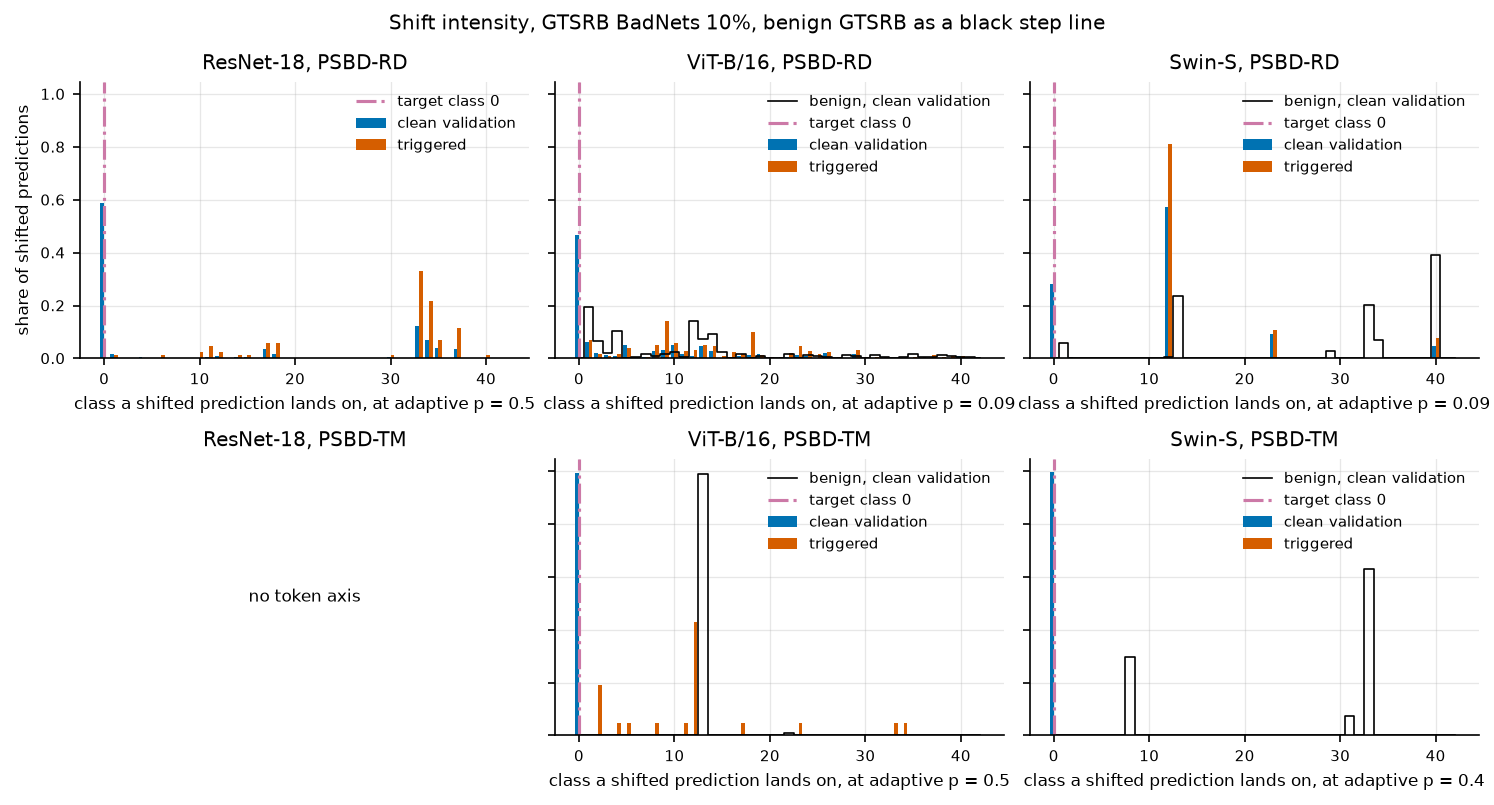

In [11]:
figure, axes = plt.subplots(2, 3, figsize=(10, 5.4), sharey=True)
for column, architecture in enumerate(ARCHITECTURES):
    record = cached[FIGURE_CELL[architecture]]
    target = record["target_label"]
    for row_index, placement in enumerate(PLACEMENTS):
        axis = axes[row_index, column]
        axis.set_title(f"{ARCHITECTURE_LABELS[architecture]}, {PLACEMENT_LABELS[placement]}")
        if placement not in record["placements"]:
            axis.text(0.5, 0.5, "no token axis", ha="center", va="center", transform=axis.transAxes)
            axis.set_axis_off()
            continue
        block = record["placements"][placement]
        landing = block["landing_at_adaptive"]
        classes = np.arange(len(landing["validation"]))
        axis.bar(classes - 0.2, landing["validation"], width=0.4, color=OKABE_ITO[0], label="clean validation")
        axis.bar(classes + 0.2, landing["backdoor"], width=0.4, color=OKABE_ITO[1], label="triggered")
        benign_folder = BENIGN_CELL.get(architecture)
        same_dataset = benign_folder and cached[benign_folder]["dataset"] == record["dataset"]
        if same_dataset and placement in cached[benign_folder]["placements"]:
            benign_landing = cached[benign_folder]["placements"][placement]["landing_at_adaptive"]
            axis.step(classes, benign_landing["validation"], where="mid", color="black", linewidth=0.8, label="benign, clean validation")
        axis.axvline(target, color=OKABE_ITO[3], linestyle="-.", label=f"target class {target}")
        axis.set_xlabel(f"class a shifted prediction lands on, at adaptive p = {block['adaptive_rate']:g}")
        if column == 0:
            axis.set_ylabel("share of shifted predictions")
        axis.legend()
figure.suptitle("Shift intensity, GTSRB BadNets 10%, benign GTSRB as a black step line")
figure.tight_layout()
plt.show()

**What the histograms show.** On ResNet-18 the target takes 0.59 of the shifted clean predictions at the adaptive p = 0.5, and 0.84 and 0.91 at p = 0.6 and 0.7, the paper's own rate. The triggered shifts land on class 33, 0.33 of them, a non-target class as in the paper's figure. On ViT-B/16 PSBD-RD sends 0.47 of the clean shifts to the target at p = 0.09 and less at every higher rate, while PSBD-TM sends 0.99. On Swin-S PSBD-RD's most frequent landing class at p = 0.09 is class 12 (0.57), with the target taking 0.28, and 1.0 at p = 0.2. PSBD-TM sends 1.0. The benign ViT under PSBD-TM sends 0.99 of its shifts to class 13, which is the paper's "universal" observation in a stronger form than the paper's own 0.6.

The paper reads the histogram at 1 rate. The next figure follows the target share of the same cell across every swept rate (purple), next to the clean validation shift ratio (blue), solid for PSBD-RD and dashed for PSBD-TM. The x axis is the rate on a log scale and the y axis a share between 0 and 1.

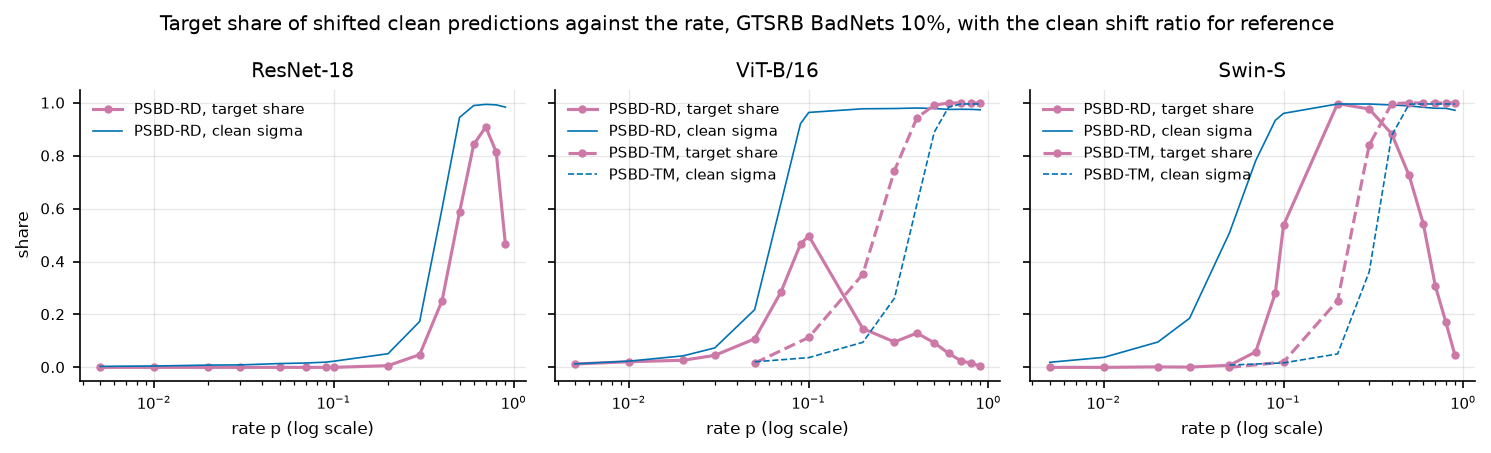

In [12]:
figure, axes = plt.subplots(1, 3, figsize=(10, 3.0), sharey=True)
for axis, architecture in zip(axes, ARCHITECTURES):
    record = cached[FIGURE_CELL[architecture]]
    for placement, style in zip(PLACEMENTS, ("-", "--")):
        if placement not in record["placements"]:
            continue
        block = record["placements"][placement]
        rates = [row["rate"] for row in block["per_rate"]]
        target_share = [row["landing"]["validation"]["target_share"] for row in block["per_rate"]]
        clean_sigma = [row["sigma"]["validation"] for row in block["per_rate"]]
        axis.plot(rates, target_share, style, color=OKABE_ITO[3], marker="o", markersize=3, label=f"{PLACEMENT_LABELS[placement]}, target share")
        axis.plot(rates, clean_sigma, style, color=OKABE_ITO[0], linewidth=0.8, label=f"{PLACEMENT_LABELS[placement]}, clean sigma")
    axis.set_xscale("log")
    axis.set_xlabel("rate p (log scale)")
    axis.set_title(ARCHITECTURE_LABELS[architecture])
    axis.legend()
axes[0].set_ylabel("share")
figure.suptitle("Target share of shifted clean predictions against the rate, GTSRB BadNets 10%, with the clean shift ratio for reference")
figure.tight_layout()
plt.show()

**What the rate sweep shows.** The target share is a hump, not a plateau, under the paper's site. On ResNet-18 it climbs from 0.25 at p = 0.4 to 0.91 at p = 0.7 and falls to 0.47 at p = 0.9. On Swin-S under PSBD-RD it reaches 1.0 at p = 0.2 and falls to 0.05 at p = 0.9, and on ViT-B/16 it peaks at 0.50 at p = 0.1 and falls to 0 at p = 0.9. At high rates PSBD-RD destroys so much of the stream that the predictions scatter. Under PSBD-TM the target share of this cell stays at 0.94 to 1.0 on both transformers at every rate past the clean curve's rise. A verdict read at 1 rate therefore depends on which rate the adaptive rule picks, which is why the verdict counts a target share of 0.8 at another saturated rate as partial.

The strip plot reads the target share of every panel model at its adaptive rate, with the benign models' largest single-class share as black crosses, and the tables count the verdicts and give the median per attack.

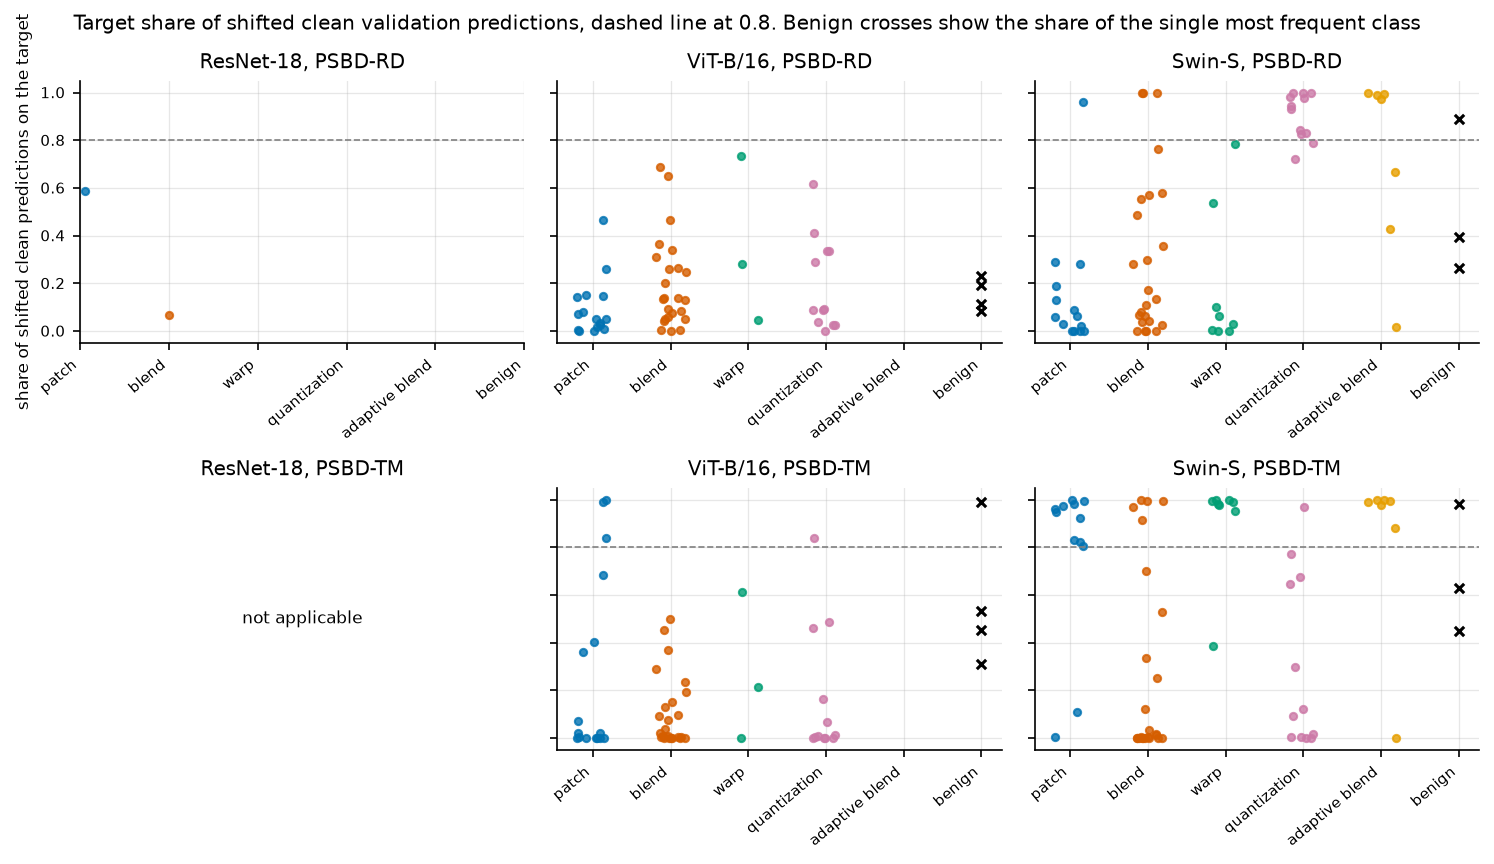

In [13]:
figure, axes = plt.subplots(2, 3, figsize=(10, 5.8), sharey=True)
for column, architecture in enumerate(ARCHITECTURES):
    for row_index, placement in enumerate(PLACEMENTS):
        axis = axes[row_index, column]
        frame = rows[(rows["architecture"] == architecture) & (rows["placement"] == placement)]
        axis.set_title(f"{ARCHITECTURE_LABELS[architecture]}, {PLACEMENT_LABELS[placement]}")
        if frame.empty:
            axis.text(0.5, 0.5, "not applicable", ha="center", va="center", transform=axis.transAxes)
            axis.set_axis_off()
            continue
        strip_plot(axis, frame, "validation_target_share", threshold=ALMOST_ALL_ON_TARGET, benign_value="validation_top_share")
        if column == 0:
            axis.set_ylabel("share of shifted clean predictions on the target")
figure.suptitle(
    f"Target share of shifted clean validation predictions, dashed line at {ALMOST_ALL_ON_TARGET}. "
    "Benign crosses show the share of the single most frequent class"
)
figure.tight_layout()
plt.show()

In [14]:
claim_2_rows = []
for architecture in ARCHITECTURES:
    for placement in PLACEMENTS:
        frame = rows[(rows["architecture"] == architecture) & (rows["placement"] == placement)]
        if frame.empty:
            continue
        poisoned, benign = frame[~frame["benign"]], frame[frame["benign"]]
        on_target_top = (poisoned["validation_top_class"] == 0) | (
            poisoned["folder"].str.contains("_tl1") & (poisoned["validation_top_class"] == 1)
        )
        claim_2_rows.append(
            {
                "architecture": ARCHITECTURE_LABELS[architecture],
                "placement": PLACEMENT_LABELS[placement],
                "poisoned models": len(poisoned),
                "verdicts": verdict_counts(poisoned, "claim_2"),
                "median target share": poisoned["validation_target_share"].median(),
                "target is the top landing class": int(on_target_top.sum()),
                "median top class share": poisoned["validation_top_share"].median(),
                "benign median top class share": benign["validation_top_share"].median() if len(benign) else np.nan,
                "benign median share on class 0": benign["validation_target_share"].median() if len(benign) else np.nan,
            }
        )
pd.DataFrame(claim_2_rows).round(3)

,architecture,placement,poisoned models,verdicts,median target share,target is the top landing class,median top class share,benign median top class share,benign median share on class 0
0,ResNet-18,PSBD-RD,2,"partial 1, fails 1",0.327,1,0.380,NaN,NaN
1,ViT-B/16,PSBD-RD,56,"fails 36, partial 20",0.089,20,0.278,0.155,0.001
2,ViT-B/16,PSBD-TM,56,"fails 41, partial 11, holds 4",0.021,15,0.559,0.494,0.001
3,Swin-S,PSBD-RD,65,"partial 30, holds 18, fails 17",0.282,32,0.573,0.393,0.000
4,Swin-S,PSBD-TM,63,"holds 29, fails 27, partial 7",0.677,34,0.914,0.629,0.000


In [15]:
(
    rows[~rows["benign"]]
    .assign(placement=lambda frame: frame["placement"].map(PLACEMENT_LABELS))
    .pivot_table(index="attack", columns=["architecture", "placement"], values="validation_target_share", aggfunc="median")
    .round(2)
)

architecture   resnet18    swin             vit          \
placement       PSBD-RD PSBD-RD PSBD-TM PSBD-RD PSBD-TM   
attack                                                    
adaptive_blend      NaN    0.97    0.99     NaN     NaN   
badnet_a2o         0.59    0.04    0.94    0.06    0.22   
blend              0.07    0.53    0.00    0.08    0.00   
bpp                 NaN    0.94    0.11    0.09    0.01   
lc                  NaN     NaN     NaN    0.00    0.00   
lf                  NaN    0.04    0.61    0.26    0.17   
tact                NaN    0.08     NaN    0.04    0.00   
wanet               NaN    0.05    0.99    0.28    0.21   

architecture                                 
placement      best residual, blocks 5 to 8  
attack                                       
adaptive_blend                          NaN  
badnet_a2o                             0.05  
blend                                  0.04  
bpp                                    0.08  
lc                                     0.00  
lf                                     0.08  
tact                                   0.04  
wanet                                  0.05

**Verdict for claim 2.**

**Claim 2 on ResNet-18 is partial.** GTSRB BadNets sends most shifted clean predictions to the target, 0.59 at the adaptive rate and 0.91 at p = 0.7, the paper's rate (the smoke run, reference only, 0.75 and 0.89). Its triggered shifts land on a single non-target class (class 33 on GTSRB, 0.33 of them), as the paper's BadNets panel shows for class 3. GTSRB Blend fails with 0.07 on the target, and class 33 leads with 0.17.

**Claim 2 on ViT-B/16 is partial under PSBD-RD and fails under PSBD-TM.** Under PSBD-RD the target leads on 20 of 56 models and takes 0.8 of the shifts on none (median 0.09). Under PSBD-TM the target leads on 15 of 56 and takes 0.8 on 4 (median 0.02). On `vit_gtsrb_tact_0_01_cos` PSBD-TM sends 0.999 of the shifted clean predictions and 0.999 of the triggered ones to class 38, not the target, and moves every triggered prediction. All 12 Blend models fail under PSBD-TM, with a median of 0.00 on the target.

**Claim 2 on Swin-S is partial under both placements.** Under PSBD-TM BadNets (10 of 12 hold, median 0.94), WaNet (7 of 8, 0.99) and Adaptive-Blend (6 of 7, 0.99) send almost every shift to the target, and Blend (0 of 12, 0.00) and BPP (1 of 12) do not. Under PSBD-RD BPP (10 of 12, 0.94) and Adaptive-Blend (4 of 7) hold and BadNets does not (median 0.04).

**The universality half of claim 2 depends on the model.** A benign transformer under PSBD-TM sends 0.99 of its GTSRB shifts (ViT) and 0.98 of its CIFAR-10 shifts (Swin) to 1 class, more than the paper's 0.6, while on CIFAR-100 and Tiny the largest class takes 0.31 to 0.45. Under PSBD-RD only the benign Swin CIFAR-10 model concentrates (0.89 on class 3).

**Why claim 2 fails where it fails, a hypothesis.** No experiment here isolates it. A perturbed transformer collapses its clean predictions onto 1 class, and whether that class is the target depends on the attack family and the architecture. The benign models show that such a collapse exists without any backdoor, so on a model whose shifts go to a non-target class, the paper's reading that dropout exposes a bias toward the target does not describe what is seen. The target share also moves strongly with the rate: on Swin GTSRB BadNets under PSBD-RD it is 0.28 at p = 0.09, 1.0 at p = 0.2 and 0.05 at p = 0.9.

**What this does not show.** The histogram is pooled over images, so 1 image that flips on all 3 passes weighs 3 times. The target share is read at 1 rate per model, and the table above shows that it moves strongly with the rate (on Swin GTSRB BadNets PSBD-RD from 0.28 at p = 0.09 to 1.0 at p = 0.2 and 0.05 at p = 0.9). A share of 0 says the target was not the landing class, not that the model has no target bias in its logits.

**Next question.** The paper explains claim 2 with neuron bias and shows the explanation with feature maps, which is claim 3.

## Step 3, the feature maps under dropout

**In plain words.** The paper looks inside the last layer. It says a clean image and the same image with the trigger look very different there, and that with dropout on they look almost the same, as if dropout pushes the clean image onto the backdoor's path. The isolating test changes 1 thing, dropout on or off, for the same image pair. The control the paper did not run is a pair of 2 unrelated clean images under the same dropout mask: if they also become almost the same, the convergence comes from the mask and not from the backdoor.

**The claim.** "Without the dropout, the features of clean and backdoor version exhibit minimal similarity ... However, under an appropriate dropout rate ... the features of clean and backdoor version become almost identical with dropout. The red boxes in the figure highlight regions where the feature map values are non-zero and the difference between each activation value in the corresponding feature maps is no greater than 1. This finding successfully confirms the validity of our neuron bias effect hypothesis." (Section 4.2, Fig. 4, with all 512 maps in Fig. A6 for BadNets and Fig. A7 for WaNet.)

**How they showed it.** Fig. 4 shows the first 64 of the 512 feature maps the last ResNet-18 layer extracts from 1 CIFAR-10 image and from the same image with the BadNets trigger, without dropout and with dropout at p = 0.91, on a colour scale from 0 to 1. With dropout most entries are 0, and the few non-zero entries of the clean and the backdoor maps sit at the same positions, so both passes must have drawn the same dropout mask. The evidence is 1 image pair and has no control: the figure does not show whether 2 unrelated images become as similar under the same mask.

**How we measure it.** `measure.measure_features` takes the first 256 captured-eligible triggered test images and their clean twins, and captures the output of the last block (`analysis.features.captured_layers`). On ResNet-18 that is the (512, 4, 4) map after the last probe and ReLU, as in Fig. 4. On ViT-B/16 the 196 patch tokens of the last block form 768 maps of 14 by 14, and on Swin-S the last block gives 768 maps of 7 by 7. Each perturbed condition runs 3 passes with 1 mask shared by the clean image and its twin, the paper's setting, and 3 passes with independent masks, which is how PSBD scores 2 inputs. The similarity is the cosine of the flattened maps after subtracting the mean unperturbed clean feature,

$$\cos(\mathbf{a},\mathbf{b}) = \frac{(\mathbf{a}-\boldsymbol\mu)^\top(\mathbf{b}-\boldsymbol\mu)}{\|\mathbf{a}-\boldsymbol\mu\|\,\|\mathbf{b}-\boldsymbol\mu\|},$$

| symbol | meaning |
|---|---|
| $\mathbf{a}$, $\mathbf{b}$ | the flattened final-layer maps of 2 images under 1 condition |
| $\boldsymbol\mu$ | the mean unperturbed clean feature over the model's 256 clean images |

because a transformer's final features share a large constant offset that makes any 2 raw ViT features look alike. The control is the same cosine between a clean image and an unrelated clean image under the same mask relation. The verdict holds when the pair's cosine under a shared mask rises by at least 0.1 to at least 0.9 and rises at least 0.1 more than the control's, it is partial when the pair converges but stays below 0.9 or converges no more than the control, and it fails when the pair does not converge. The conditions are the paper's p = 0.91 and each placement's adaptive rate.

The first figures reproduce Fig. 4 for the GTSRB BadNets cell on each architecture: rows are conditions, the left column the clean image and the right column its triggered twin, each panel the first 64 channel maps in an 8 by 8 mosaic. Red boxes mark the channels that pass the paper's test (both maps non-zero, every entry within 1). ResNet-18 uses the paper's 0 to 1 scale. The transformers use a symmetric scale at the 99th percentile of the unperturbed absolute activations, since their maps are signed.

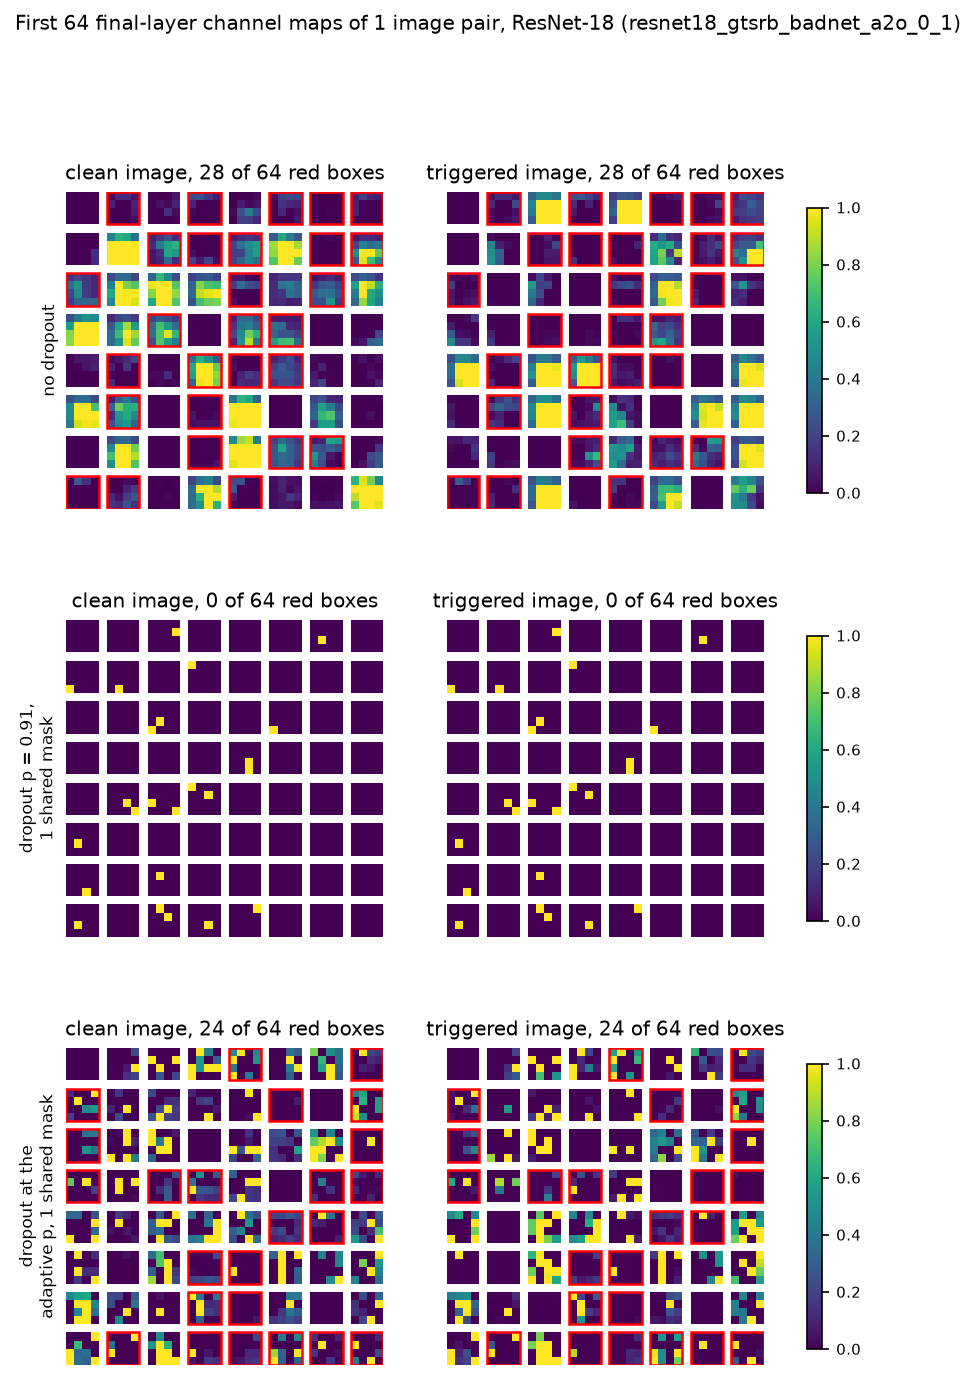

In [16]:
def mosaic(channel_maps, columns=8, gap=1):
    stack = np.asarray(channel_maps, dtype=float)  # (64, height, width)
    count, height, width = stack.shape
    grid_rows = count // columns
    canvas = np.full((grid_rows * (height + gap) - gap, columns * (width + gap) - gap), np.nan)
    for index in range(count):
        grid_row, grid_column = divmod(index, columns)
        top, left = grid_row * (height + gap), grid_column * (width + gap)
        canvas[top : top + height, left : left + width] = stack[index]
    return canvas, (height, width, gap, columns)


def paper_red_boxes(clean_maps, triggered_maps):
    clean, triggered = np.asarray(clean_maps), np.asarray(triggered_maps)  # (64, h, w)
    active = (np.abs(clean).reshape(len(clean), -1).max(axis=1) > 0) & (
        np.abs(triggered).reshape(len(triggered), -1).max(axis=1) > 0
    )
    close = np.abs(clean - triggered).reshape(len(clean), -1).max(axis=1) <= PAPER_MATCH_TOLERANCE
    boxes = active & close  # (64,)
    return boxes


def draw_maps(folder, conditions):
    record = feature_maps[folder]
    architecture = record["architecture"]
    figure, axes = plt.subplots(len(conditions), 2, figsize=(7.5, 3.5 * len(conditions)))
    reference = np.abs(np.asarray(record["maps"]["unperturbed"]["clean"]))
    if architecture == "resnet18":
        color_map, low, high = "viridis", 0.0, 1.0
    else:
        limit = float(np.quantile(reference, 0.99))
        color_map, low, high = "coolwarm", -limit, limit
    for row_index, (condition, label) in enumerate(conditions.items()):
        maps = record["maps"][condition]
        boxes = paper_red_boxes(maps["clean"], maps["triggered"])
        for column, image in enumerate(("clean", "triggered")):
            axis = axes[row_index, column]
            canvas, (height, width, gap, columns) = mosaic(maps[image])
            shown = axis.imshow(canvas, cmap=color_map, vmin=low, vmax=high, interpolation="nearest")
            for index in np.flatnonzero(boxes):
                grid_row, grid_column = divmod(index, columns)
                axis.add_patch(
                    Rectangle(
                        (grid_column * (width + gap) - 0.5, grid_row * (height + gap) - 0.5),
                        width,
                        height,
                        fill=False,
                        edgecolor="red",
                        linewidth=1.2,
                    )
                )
            axis.set_title(f"{image} image, {int(boxes.sum())} of 64 red boxes")
            axis.set_xticks([])
            axis.set_yticks([])
            for spine in axis.spines.values():
                spine.set_visible(False)
        axes[row_index, 0].set_ylabel(label, fontsize=8)
        figure.colorbar(shown, ax=axes[row_index].tolist(), shrink=0.8)
    figure.suptitle(f"First 64 final-layer channel maps of 1 image pair, {ARCHITECTURE_LABELS[architecture]} ({folder})")
    plt.show()


if "resnet18_gtsrb_badnet_a2o_0_1" in feature_maps:
    draw_maps(
        "resnet18_gtsrb_badnet_a2o_0_1",
        {
            "unperturbed": "no dropout",
            "rd_paper": f"dropout p = {PAPER_FEATURE_RATE},\n1 shared mask",
            "rd_adaptive": "dropout at the\nadaptive p, 1 shared mask",
        },
    )

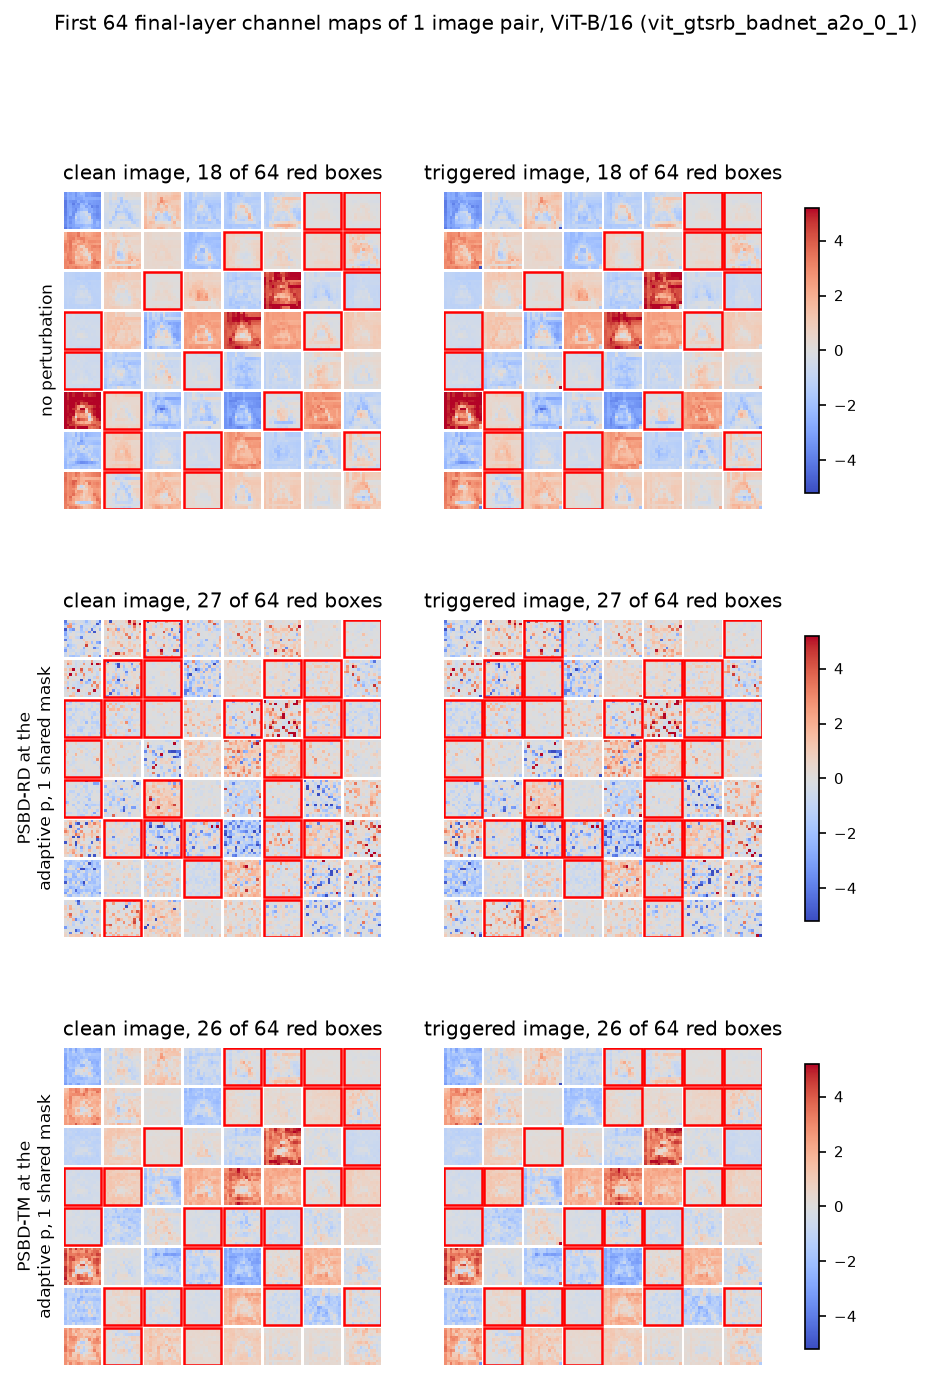

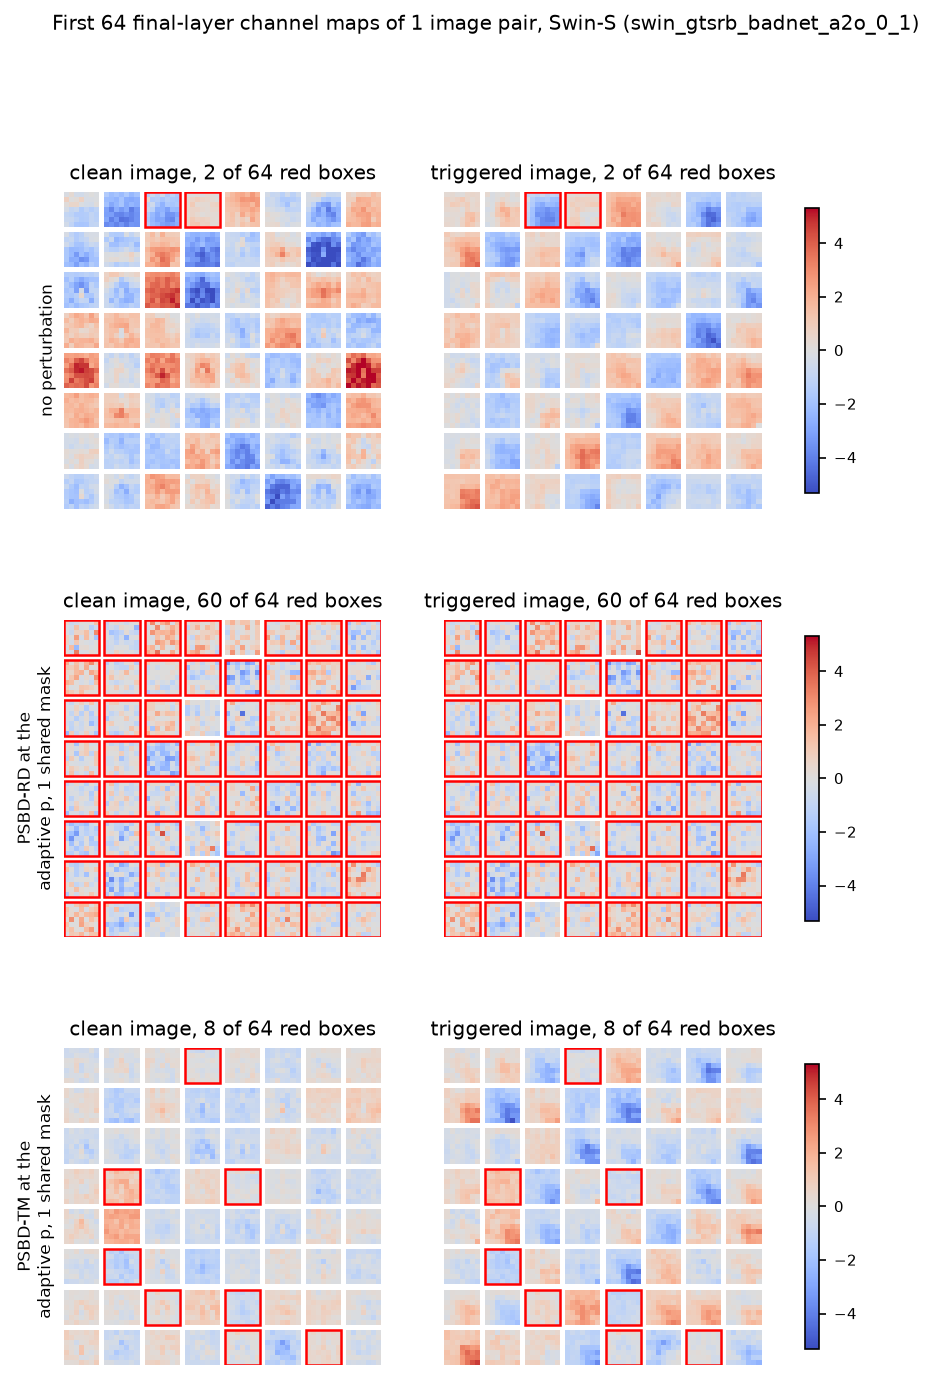

In [17]:
for architecture in ("vit", "swin"):
    folder = FIGURE_CELL[architecture]
    if folder not in feature_maps:
        print(f"{folder} has no feature maps yet")
        continue
    draw_maps(
        folder,
        {
            "unperturbed": "no perturbation",
            "rd_adaptive": "PSBD-RD at the\nadaptive p, 1 shared mask",
            "tm_adaptive": "PSBD-TM at the\nadaptive p, 1 shared mask",
        },
    )

**What the maps show.** On ResNet-18 the unperturbed maps of the clean image and its twin differ in most channels. At p = 0.91 with 1 shared mask both are almost entirely 0 and the few surviving entries sit at the same positions in both images, which is the look of the paper's Fig. 4. On the transformers PSBD-RD at the adaptive rate scatters the maps into noise that again matches between the 2 images, and PSBD-TM leaves the maps close to their unperturbed form. The red-box count depends on the activation scale (the transformers' activations run to about 5), so the scale-free cosines below carry the comparison.

The next figure puts every model on 1 row and each condition in its own panel. Open blue circles are the pair without perturbation, filled blue circles the pair under a shared mask, green triangles the pair under independent masks and orange crosses 2 unrelated clean images under a shared mask. The x axis is the centered cosine and the dashed line the 0.9 the verdict calls almost identical. A pair that converges for a backdoor reason sits right of its orange cross.

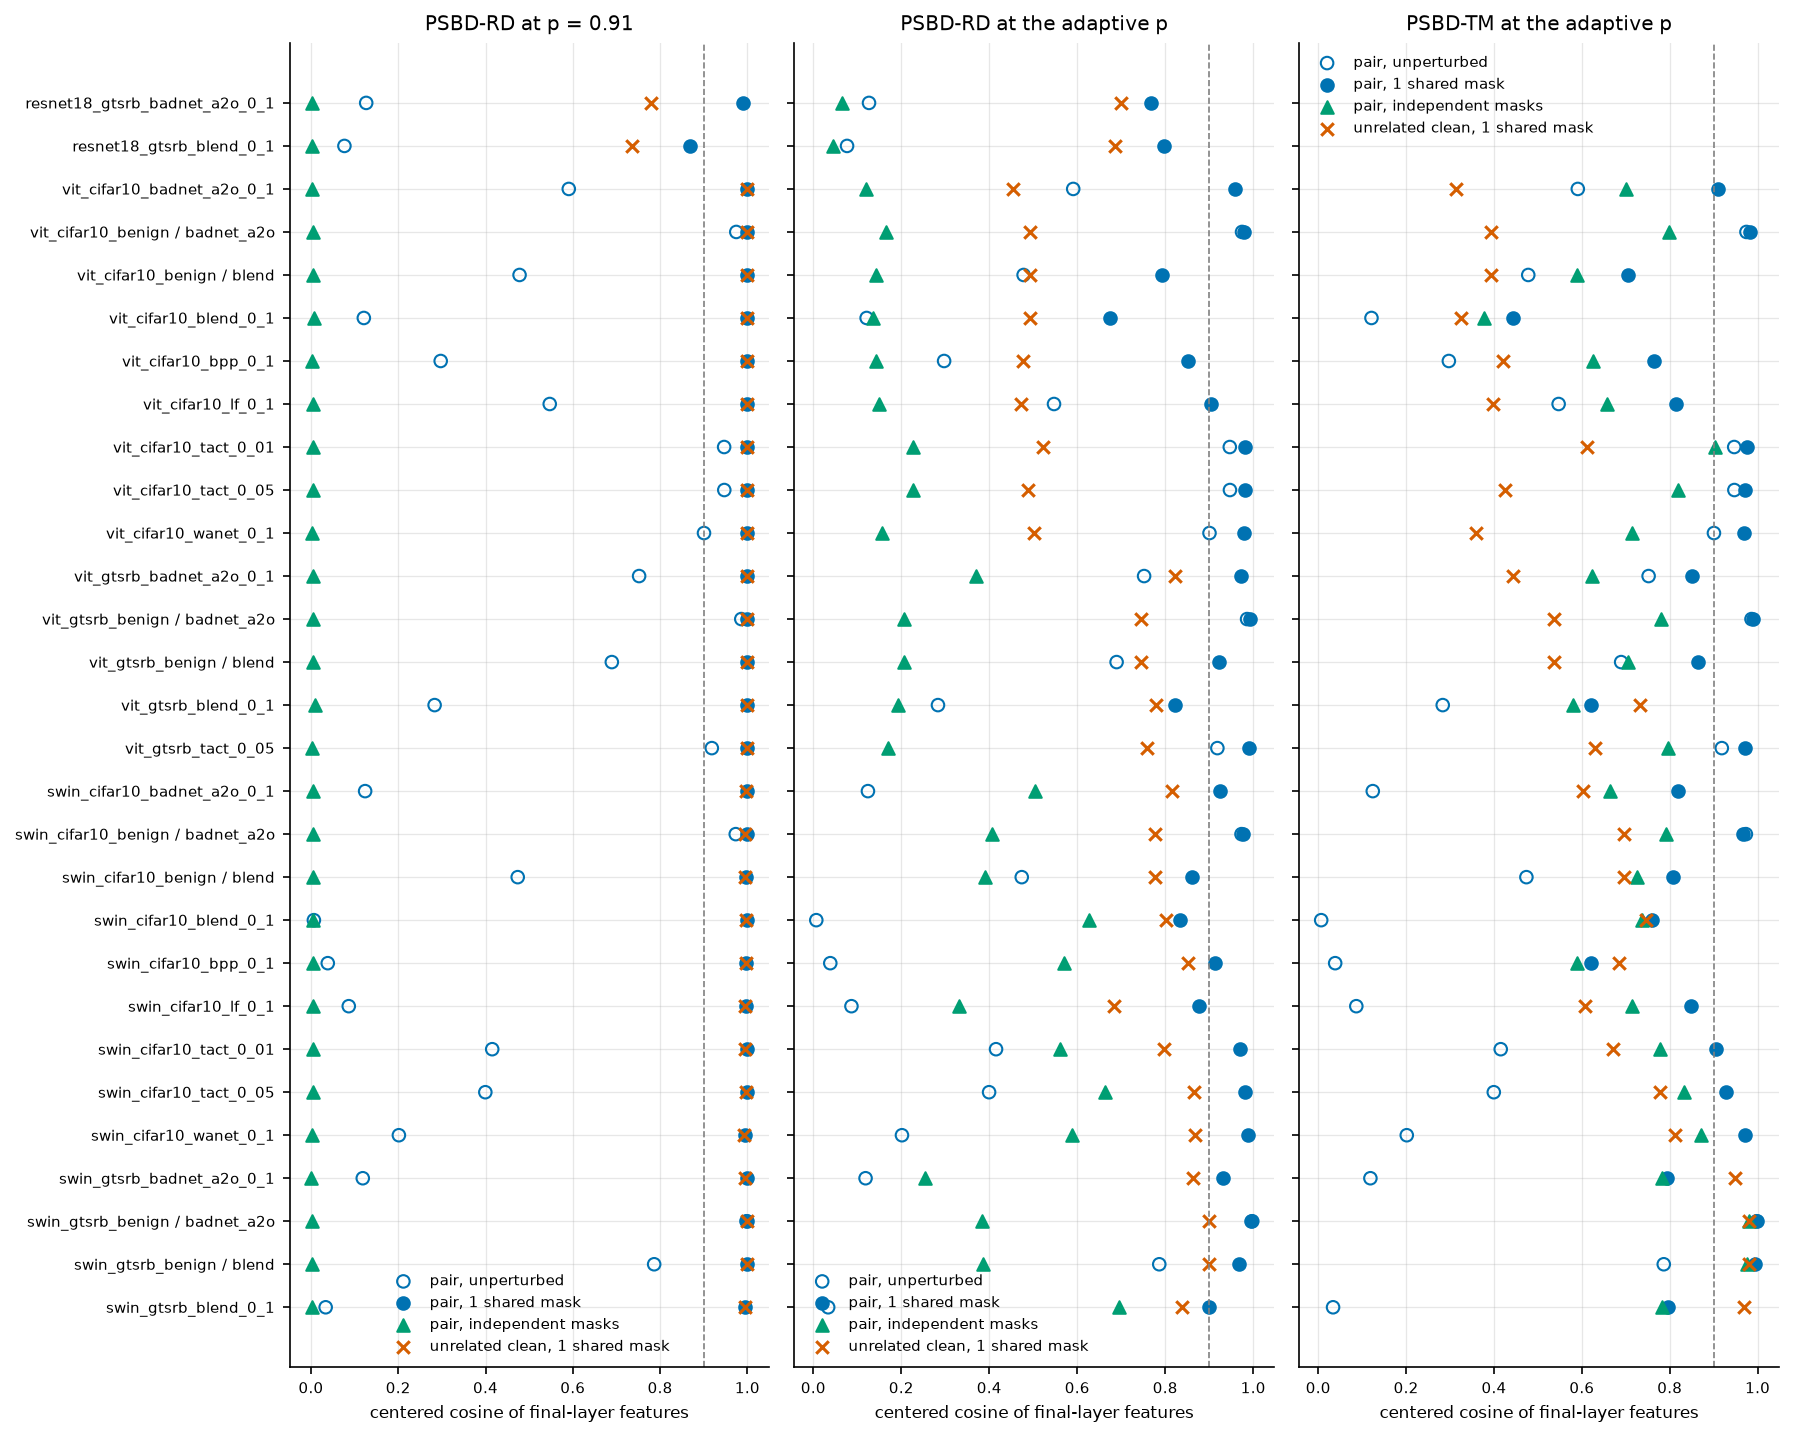

In [18]:
CONDITION_LABELS = {
    "rd_paper": f"PSBD-RD at p = {PAPER_FEATURE_RATE}",
    "rd_adaptive": "PSBD-RD at the adaptive p",
    "tm_adaptive": "PSBD-TM at the adaptive p",
}
assert not feature_rows.empty, "no feature readings yet, run the features stage first"
readable = feature_rows.copy()
readable["model"] = readable["folder"] + np.where(readable["probe"] != readable["attack"], " / " + readable["probe"], "")
figure, axes = plt.subplots(1, 3, figsize=(12, 0.28 * readable["model"].nunique() + 1.5), sharey=True)
order = sorted(readable["model"].unique(), key=lambda name: (ARCHITECTURES.index(name.split("_")[0]), name))
positions = {name: index for index, name in enumerate(order)}
for axis, (condition, label) in zip(axes, CONDITION_LABELS.items()):
    frame = readable[readable["condition"] == condition]
    y = frame["model"].map(positions)
    axis.scatter(frame["cosine_pair_off"], y, facecolors="none", edgecolors=OKABE_ITO[0], label="pair, unperturbed")
    axis.scatter(frame["cosine_pair_shared"], y, color=OKABE_ITO[0], label="pair, 1 shared mask")
    axis.scatter(frame["cosine_pair_independent"], y, color=OKABE_ITO[2], marker="^", label="pair, independent masks")
    axis.scatter(frame["cosine_unrelated_on"], y, color=OKABE_ITO[1], marker="x", label="unrelated clean, 1 shared mask")
    axis.axvline(IDENTICAL_COSINE, color="grey", linestyle="--", linewidth=0.8)
    axis.set_title(label)
    axis.set_xlabel("centered cosine of final-layer features")
    axis.legend()
axes[0].set_yticks(range(len(order)))
axes[0].set_yticklabels(order)
axes[0].invert_yaxis()
figure.tight_layout()
plt.show()

In [19]:
columns = [
    "folder", "probe", "condition", "rate", "cosine_pair_off", "cosine_pair_shared", "cosine_pair_independent",
    "cosine_unrelated_off", "cosine_unrelated_on", "cka_pair_off", "cka_pair_on", "paper_share_off",
    "paper_share_on", "clean_self", "triggered_self", "clean_toward_triggered_off",
    "clean_toward_triggered_on", "clean_on_target", "triggered_on_target", "claim_3",
]
feature_rows[columns].round(3)

,folder,probe,condition,rate,cosine_pair_off,cosine_pair_shared,cosine_pair_independent,cosine_unrelated_off,cosine_unrelated_on,cka_pair_off,cka_pair_on,paper_share_off,paper_share_on,clean_self,triggered_self,clean_toward_triggered_off,clean_toward_triggered_on,clean_on_target,triggered_on_target,claim_3
2,resnet18_gtsrb_badnet_a2o_0_1,badnet_a2o,rd_adaptive,0.50,0.127,0.767,0.066,0.026,0.700,0.826,0.331,0.376,0.372,0.041,0.334,0.127,0.086,0.555,0.999,fails
3,resnet18_gtsrb_badnet_a2o_0_1,badnet_a2o,rd_paper,0.91,0.127,0.989,0.003,0.026,0.779,0.826,0.990,0.376,0.044,-0.000,0.010,0.127,0.009,0.384,0.427,holds
4,resnet18_gtsrb_blend_0_1,blend,rd_adaptive,0.50,0.077,0.796,0.044,0.024,0.685,0.384,0.601,0.334,0.273,0.037,0.156,0.077,0.012,0.060,0.725,fails
5,resnet18_gtsrb_blend_0_1,blend,rd_paper,0.91,0.077,0.869,0.003,0.024,0.735,0.384,0.746,0.334,0.002,-0.001,-0.014,0.077,-0.014,0.042,0.048,fails
6,swin_cifar10_badnet_a2o_0_1,badnet_a2o,rd_adaptive,0.09,0.124,0.925,0.503,0.006,0.815,0.421,0.863,0.012,0.540,0.054,0.363,0.124,0.184,0.949,0.987,fails
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
96,vit_gtsrb_blend_0_1,blend,br_adaptive,0.50,0.283,0.740,0.303,0.008,0.769,0.334,0.466,0.249,0.226,0.357,0.618,0.283,0.189,0.000,1.000,fails
97,vit_gtsrb_tact_0_05,tact,rd_adaptive,0.09,0.919,0.990,0.171,0.005,0.758,0.996,0.993,0.701,0.664,0.116,0.128,0.919,0.111,0.004,0.022,fails
98,vit_gtsrb_tact_0_05,tact,rd_paper,0.91,0.919,1.000,0.003,0.005,1.000,0.996,1.000,0.701,0.992,-0.000,0.001,0.919,0.000,0.017,0.008,fails
99,vit_gtsrb_tact_0_05,tact,tm_adaptive,0.50,0.919,0.970,0.795,0.005,0.631,0.996,0.996,0.701,0.700,0.377,0.416,0.919,0.349,0.000,0.572,fails


**Verdict for claim 3.** The table above gives every reading, and these are its medians.

**The observation reproduces and its reading fails the control, on all 3 architectures.** With 1 dropout mask shared by the clean image and its twin, as in Fig. 4, the pair's final-layer features do become almost identical: the median cosine at p = 0.91 is 0.93 on ResNet-18 and 1.00 on both transformers, from 0.10, 0.67 and 0.12 without dropout. But 2 unrelated clean images under the same shared mask converge too, to 0.76 on ResNet-18 and to 1.00 on both transformers, and they converge on the benign models as much as on the poisoned ones. The convergence is the mask: at p = 0.91 the mask decides which entries are 0, so any 2 inputs that share it look alike. Only 1 of 61 poisoned readings holds by the rule (ResNet-18 GTSRB BadNets at p = 0.91, pair 0.99 against unrelated 0.78). With independent masks, which is how PSBD actually scores 2 inputs, the pair is no more similar than 2 unrelated images (medians 0.00 at p = 0.91 on every architecture, and at the adaptive rate 0.05 against 0.05 on ResNet-18, 0.16 against 0.12 on ViT under PSBD-RD).

**Neuron bias as a drift toward the backdoor's features appears on Swin-S only.** If dropout pushed clean images onto the backdoor path, the perturbed clean feature should move toward its triggered twin's unperturbed feature. That cosine falls under the perturbation on ResNet-18 (0.10 to 0.05) and ViT-B/16 (0.67 to 0.15 under PSBD-RD, 0.33 under PSBD-TM) and on every benign model. On poisoned Swin-S models it rises, from 0.12 to 0.32 under PSBD-RD and to 0.35 under PSBD-TM, while on the benign Swin models it falls from 0.88 to 0.05 and 0.03. The benign models are the control, so this is the 1 reading in this experiment consistent with the paper's account, and it is a partial move, not identity.

**What claim 3 does not show.** 9 to 10 models per transformer and 2 ResNet-18 models plus the smoke run, 1 per attack family, mostly CIFAR-10 and GTSRB at 10%. The final block's patch tokens stand in for ResNet-18's top layer. The pooled feature the classifier head reads is in the JSON (`cosine_pooled_*`) and tells the same story.

**Next question.** Claims 1 to 3 describe the phenomenon. Claim 4 asks why PSBD scores a drop in confidence rather than the textbook uncertainty.

## Step 4, the MC-Dropout pilot study

**In plain words.** Before PSBD, the authors tried the textbook uncertainty score: run dropout a few times and measure how much the top confidence wobbles. They expected triggered images to wobble less. It worked on BadNets and failed on WaNet, which is why they switched to measuring how far the confidence drops. The isolating test scores the same cached passes 2 ways, wobble and drop, so the statistic is the only thing that changes.

**The claim.** "The average uncertainty of backdoor training data under BadNets is significantly lower than that of clean training and validation data ... However, in Figure 2b, the uncertainty of backdoor data under WaNet sometimes matches or exceeds that of clean data", and in the appendix, "under Adaptive-Blend attack, we can observe that the uncertainty of backdoor training data is even slightly higher than clean training data". Their conclusion is that "using uncertainty based on standard deviation may be insufficient for detecting backdoor data across different attack scenarios", which is why PSBD scores the drop in confidence instead. (Section 4.1, Fig. 2, Fig. A1.)

**How they showed it.** Fig. 2 plots, for each of the 100 training epochs, the mean MC-Dropout uncertainty (the standard deviation of the highest-confidence class over the dropout passes) of clean training, backdoor training and clean validation images. On BadNets the backdoor curve sits well below the others after about epoch 50. On WaNet the backdoor curve crosses above the clean curves in many epochs before 50 and ends at about 0.08 against 0.10 for clean training and 0.16 for validation. The rate is not stated.

**How we measure it.** Per image, the population standard deviation over the k = 3 passes of the probability of the unperturbed argmax class,

$$u(\mathbf{x}) = \sqrt{\frac{1}{k}\sum_{i=1}^{k}\left(P_c(\mathbf{x};p,\boldsymbol\theta'_i)-\bar{P}_c(\mathbf{x})\right)^2},$$

| symbol | meaning |
|---|---|
| $P_c(\mathbf{x};p,\boldsymbol\theta'_i)$ | probability of the unperturbed argmax class c on pass i at rate p |
| $\bar{P}_c(\mathbf{x})$ | its mean over the k passes |

computed in `measure.per_sample_scores` from the cached per-pass probabilities. We have final checkpoints only, so the epoch axis is replaced by the rate axis. Low $u$ is scored as poisoned, and its AUROC between the clean twins and the captured triggered images is compared with the AUROC of fractional PSU at the adaptive rate (the repository's headline statistic, `defenses.scores.psu_ratio_from_cache`). Since the paper never gives its rate, the standard deviation is also read at its best rate, an oracle. On 1 model the standard deviation fails when its best rate loses to PSU by more than 0.05. The architecture verdict holds when the standard deviation suffices on most BadNets models and fails on most WaNet and Adaptive-Blend models, as the pilot study says.

The first figure draws the mean standard deviation against the rate for a BadNets model (blue) and a WaNet model (orange) of each architecture, solid for clean twins and dashed for captured triggered images, with each model's adaptive rate dotted. ResNet-18 has no WaNet model, so its orange lines are GTSRB Blend, and ViT's WaNet model is CIFAR-10 because its GTSRB WaNet model fails the 2-point bar.

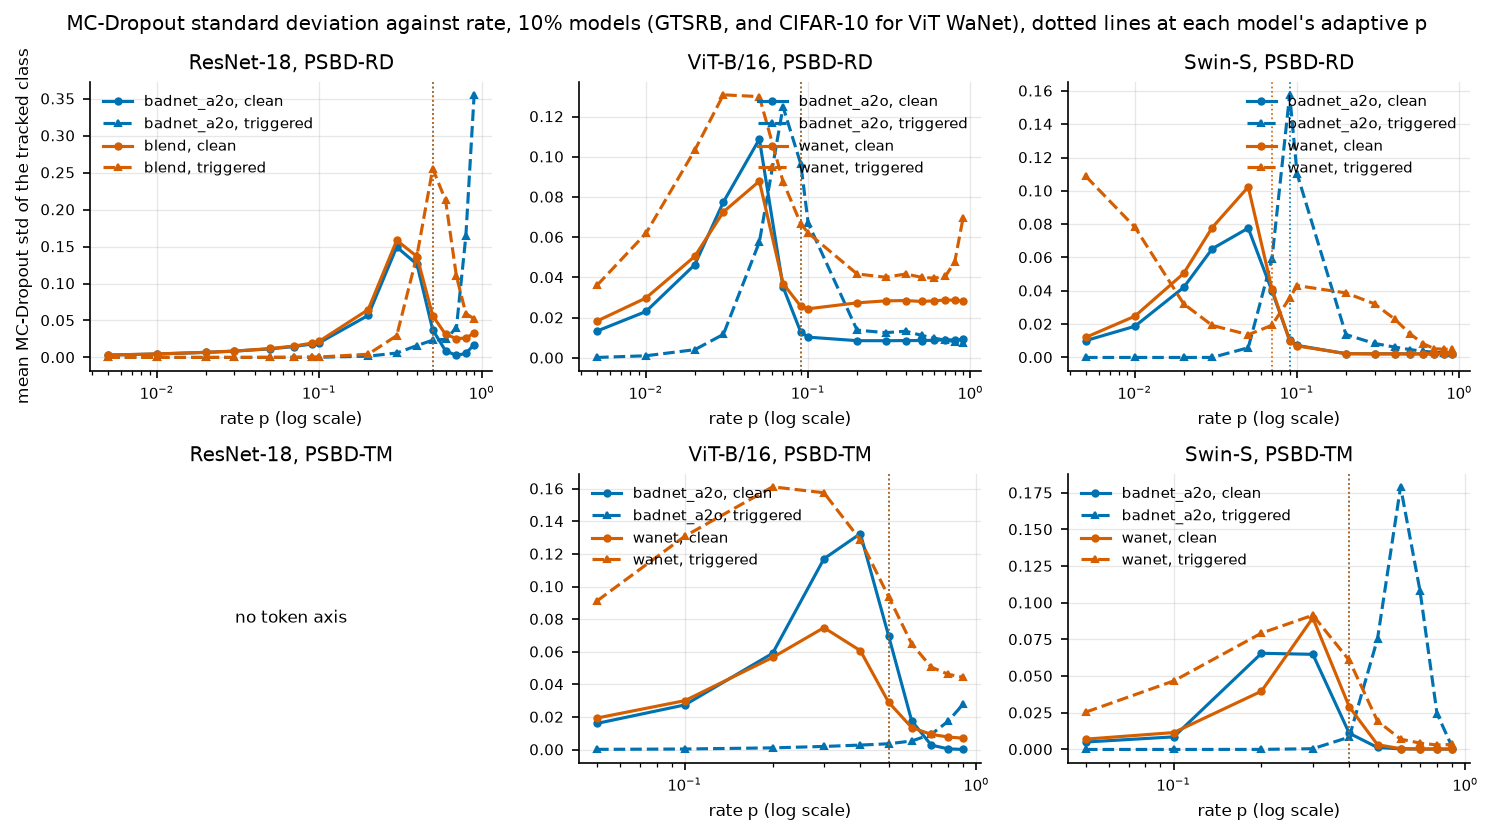

In [20]:
STD_MODELS = {
    "resnet18": ("resnet18_gtsrb_badnet_a2o_0_1", "resnet18_gtsrb_blend_0_1"),
    "vit": ("vit_gtsrb_badnet_a2o_0_1", "vit_cifar10_wanet_0_1"),
    "swin": ("swin_gtsrb_badnet_a2o_0_1", "swin_gtsrb_wanet_0_1"),
}
figure, axes = plt.subplots(2, 3, figsize=(10, 5.6))
for column, architecture in enumerate(ARCHITECTURES):
    for row_index, placement in enumerate(PLACEMENTS):
        axis = axes[row_index, column]
        axis.set_title(f"{ARCHITECTURE_LABELS[architecture]}, {PLACEMENT_LABELS[placement]}")
        drawn = False
        for color, folder in zip((OKABE_ITO[0], OKABE_ITO[1]), STD_MODELS[architecture]):
            record = cached[folder]
            if placement not in record["placements"]:
                continue
            attack = record["attack"]
            rates, clean = rate_series(record, placement, "std_mean", "clean_paired")
            _, triggered = rate_series(record, placement, "std_mean", "backdoor")
            axis.plot(rates, clean, "-", color=color, marker="o", markersize=3, label=f"{attack}, clean")
            axis.plot(rates, triggered, "--", color=color, marker="^", markersize=3, label=f"{attack}, triggered")
            axis.axvline(record["placements"][placement]["adaptive_rate"], color=color, linestyle=":", linewidth=0.8)
            drawn = True
        if not drawn:
            axis.text(0.5, 0.5, "no token axis", ha="center", va="center", transform=axis.transAxes)
            axis.set_axis_off()
            continue
        axis.set_xscale("log")
        axis.set_xlabel("rate p (log scale)")
        if column == 0:
            axis.set_ylabel("mean MC-Dropout std of the tracked class")
        axis.legend()
figure.suptitle("MC-Dropout standard deviation against rate, 10% models (GTSRB, and CIFAR-10 for ViT WaNet), dotted lines at each model's adaptive p")
figure.tight_layout()
plt.show()

**What the curves show.** The standard deviation is not monotone in the rate. It peaks where predictions are about to flip and falls to near 0 once they all have, because a prediction that moves on every pass is as consistent as one that never moves. At the adaptive rate the clean images are past their peak, so on most models the clean standard deviation there is below the triggered one and the ordering the pilot study expects is inverted (ViT GTSRB BadNets PSBD-RD 0.013 clean against 0.096 triggered). At low rates BadNets behaves as the paper says on every architecture: the triggered standard deviation stays near 0 while the clean one rises. WaNet does not: its triggered curve lies above or on the clean curve at low rates on both transformers, which is the pilot study's WaNet observation.

The scatter plots 1 point per model, the AUROC of the standard deviation at its best rate against the AUROC of fractional PSU at the adaptive rate. A point below the dashed line loses to PSU by more than 0.05. The table gives medians per attack for the attacks the pilot study names.

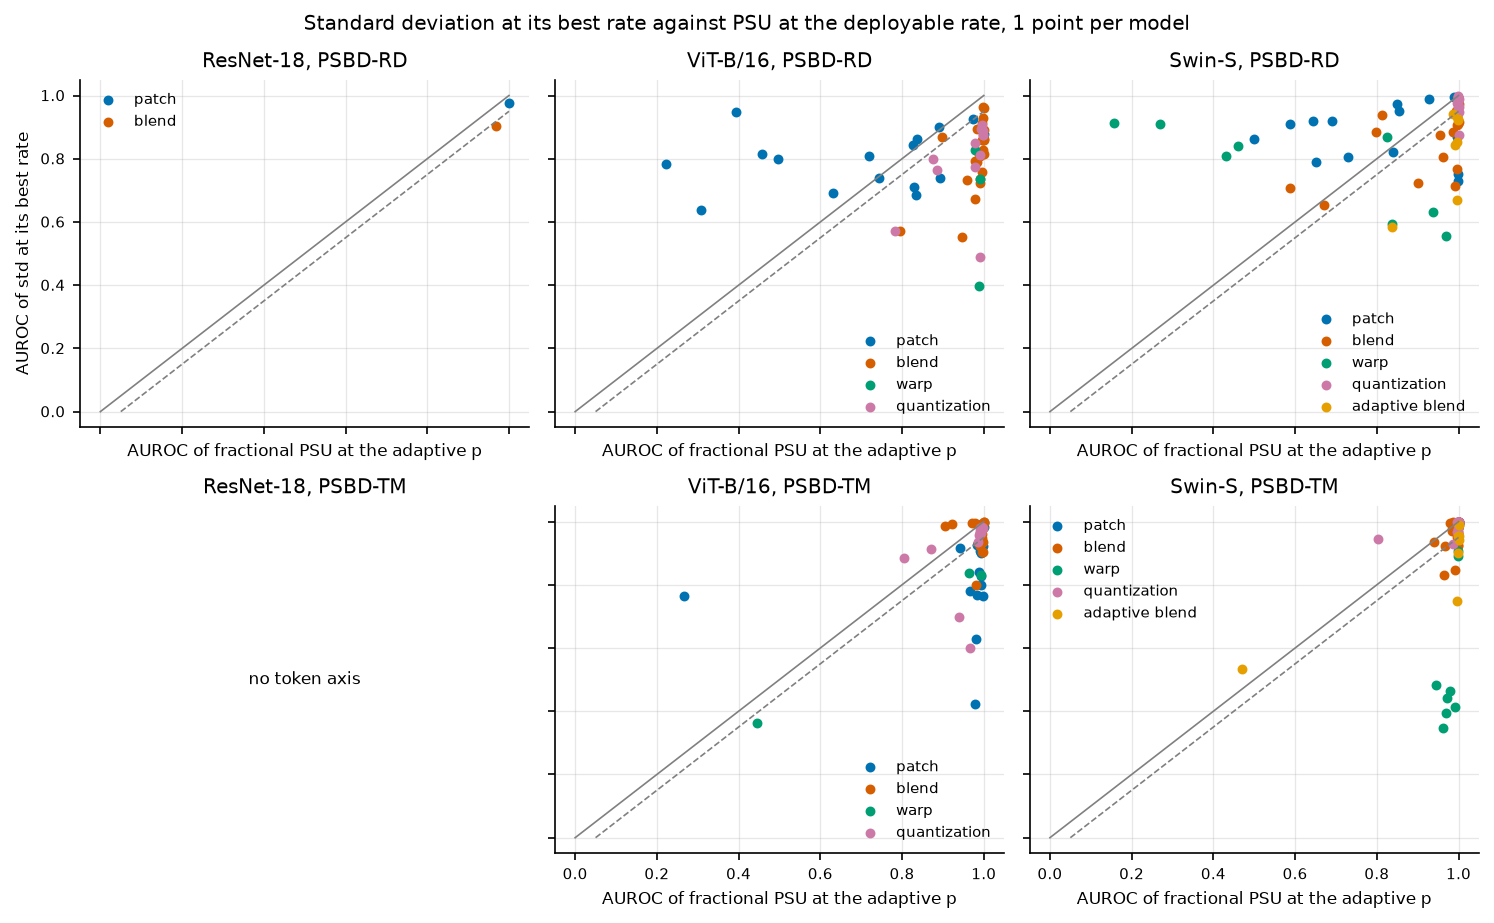

In [21]:
figure, axes = plt.subplots(2, 3, figsize=(10, 6.2), sharex=True, sharey=True)
for column, architecture in enumerate(ARCHITECTURES):
    for row_index, placement in enumerate(PLACEMENTS):
        axis = axes[row_index, column]
        frame = rows[(rows["architecture"] == architecture) & (rows["placement"] == placement) & ~rows["benign"]]
        axis.set_title(f"{ARCHITECTURE_LABELS[architecture]}, {PLACEMENT_LABELS[placement]}")
        if frame.empty:
            axis.text(0.5, 0.5, "no token axis", ha="center", va="center", transform=axis.transAxes)
            axis.set_axis_off()
            continue
        for category in CATEGORY_ORDER:
            subset = frame[frame["category"] == category]
            if subset.empty:
                continue
            axis.scatter(subset["auroc_psu_ratio"], subset["auroc_std_best_rate"], s=14, color=CATEGORY_COLORS[category], label=category)
        axis.plot([0, 1], [0, 1], color="grey", linewidth=0.8)
        axis.plot([STD_LOSES_BY, 1], [0, 1 - STD_LOSES_BY], color="grey", linestyle="--", linewidth=0.8)
        axis.set_xlabel("AUROC of fractional PSU at the adaptive p")
        if column == 0:
            axis.set_ylabel("AUROC of std at its best rate")
        axis.legend()
figure.suptitle("Standard deviation at its best rate against PSU at the deployable rate, 1 point per model")
figure.tight_layout()
plt.show()

In [22]:
claim_4_rows = []
for architecture in ARCHITECTURES:
    for placement in PLACEMENTS:
        frame = rows[(rows["architecture"] == architecture) & (rows["placement"] == placement) & ~rows["benign"]]
        for attack, subset in frame.groupby("attack"):
            claim_4_rows.append(
                {
                    "architecture": ARCHITECTURE_LABELS[architecture],
                    "placement": PLACEMENT_LABELS[placement],
                    "attack": attack,
                    "models": len(subset),
                    "std fails": int((subset["claim_4"] == "std fails").sum()),
                    "median std AUROC at adaptive p": subset["auroc_std"].median(),
                    "median std AUROC at best p": subset["auroc_std_best_rate"].median(),
                    "median PSU ratio AUROC": subset["auroc_psu_ratio"].median(),
                    "median clean std": subset["std_clean_paired"].median(),
                    "median triggered std": subset["std_backdoor"].median(),
                }
            )
claim_4 = pd.DataFrame(claim_4_rows).round(3)
claim_4[claim_4["attack"].isin(["badnet_a2o", "wanet", "adaptive_blend", "blend"])]

,architecture,placement,attack,models,std fails,median std AUROC at adaptive p,median std AUROC at best p,median PSU ratio AUROC,median clean std,median triggered std
0,ResNet-18,PSBD-RD,badnet_a2o,1,0,0.706,0.975,1.000,0.037,0.023
1,ResNet-18,PSBD-RD,blend,1,1,0.089,0.903,0.968,0.057,0.255
2,ViT-B/16,PSBD-RD,badnet_a2o,12,2,0.223,0.804,0.785,0.013,0.030
3,ViT-B/16,PSBD-RD,blend,12,9,0.054,0.844,0.997,0.013,0.103
8,ViT-B/16,PSBD-RD,wanet,3,3,0.063,0.737,0.990,0.016,0.147
9,ViT-B/16,PSBD-TM,badnet_a2o,12,10,0.117,0.871,0.993,0.016,0.137
10,ViT-B/16,PSBD-TM,blend,12,2,0.602,0.992,0.995,0.017,0.010
15,ViT-B/16,PSBD-TM,wanet,3,3,0.300,0.832,0.965,0.024,0.094
16,Swin-S,PSBD-RD,adaptive_blend,7,6,0.643,0.852,0.995,0.033,0.008
17,Swin-S,PSBD-RD,badnet_a2o,12,1,0.185,0.916,0.784,0.027,0.096


**Verdict for claim 4.**

**Claim 4 holds on ViT-B/16 under PSBD-RD and on Swin-S under PSBD-TM.** It is partial on ViT-B/16 under PSBD-TM and on Swin-S under PSBD-RD, and only its BadNets half can be read on ResNet-18, where it holds. The standard deviation fails on every WaNet model of both transformers except 5 of 8 Swin models under PSBD-RD. At its best rate its median AUROC on WaNet is 0.74 and 0.83 on ViT (PSBD-RD and PSBD-TM) and 0.45 on Swin under PSBD-TM, against PSU medians of 0.97 to 0.99. On BadNets it suffices on ResNet-18 GTSRB (0.98 against 1.00) and on Swin-S under PSBD-TM (0.99 against 1.00). The partial verdicts come from the other half. Under PSBD-TM on ViT the standard deviation also loses on 10 of 12 BadNets models (median 0.87 against 0.99), and under PSBD-RD on Swin Adaptive-Blend fails on 6 of 7 but WaNet on only 3 of 8, because PSU itself is weak on Swin WaNet under PSBD-RD (median 0.64).

**Why the standard deviation fails.** The rate sweep of the standard deviation (notebook step 4, first figure) is the isolating test, since it changes only the rate and scores the same passes 2 ways. The standard deviation is not monotone in the rate. A prediction that flips on every pass has as little spread as one that never flips, so it peaks where predictions are about to flip and falls once they have. At the adaptive rate the clean images are past their peak, and the median standard deviation AUROC there is 0.10 to 0.47, mostly below chance: the clean images look more certain than the triggered ones. PSU reads the drop in confidence, which keeps growing with the rate.

**What this does not show.** The paper's figure follows the uncertainty over training epochs and reads training images. Ours reads 1 final checkpoint and test images, so the "sometimes" in "sometimes matches or exceeds" (the epochs where WaNet's backdoor curve crosses the clean one) has no counterpart here. The best-rate reading flatters the standard deviation, since it picks the rate with the backdoor labels, and the verdict holds even so. The SCP variant of Fig. A2 was not run.

## Step 5, the best residual placement

**In plain words.** The best placement that masks no tokens detects backdoors almost as well as PSBD-TM. If the paper's neuron bias were the reason, this placement would send clean images to the target when it changes their answers, and would push their inner features toward the triggered image's. This step changes only the placement and keeps the benign models and the unrelated image pair as controls.

**Question.** The best placement that masks no tokens is `pre_residual_blocks_5_8`, dropout before both residual adds in blocks 5 to 8 only (`\BestResidualName` in `paper/headline.tex`). It trails PSBD-TM by `\BestResidualGain` on the headline panel. Does it detect through neuron bias, the mechanism the paper proposes? If it did, its shifted clean predictions would land on the target (claim 2), more often than on a benign model of the same dataset, and its perturbed clean features would move toward their triggered twins (claim 3).

**Method.** The same 3 measurements, changing only the placement: claims 1 and 2 from its stage-1 caches on the 56 successful ViT-B/16 models and the 4 ViT benign models, and claim 3 on the 10 ViT feature models and 2 benign ones at its adaptive rate, added to the existing records with `--add-conditions br_adaptive` (`run_best_residual_gpu.sh`, GPU 21:30 to 00:59 on 2026-09-29, mostly waiting for a lock slot). The control for claim 2 is `target_share_over_benign`, the target share minus the share the benign model of the same dataset sends to that class. The control for claim 3 is the benign models and the unrelated image pair.

The figure has 3 panels, 1 point per model at its adaptive rate, grouped by attack. The left panel is the triggered shift ratio (claim 1, dashed line at 0.1). The middle panel is the share of shifted clean predictions on the target (claim 2, dashed line at 0.8), with the benign models' share on class 0 as black crosses. The right panel is that share minus the benign model's share on the same class, the control, with 0 dashed. The first table below counts verdicts per attack and the second gives the claim 3 readings of this placement.

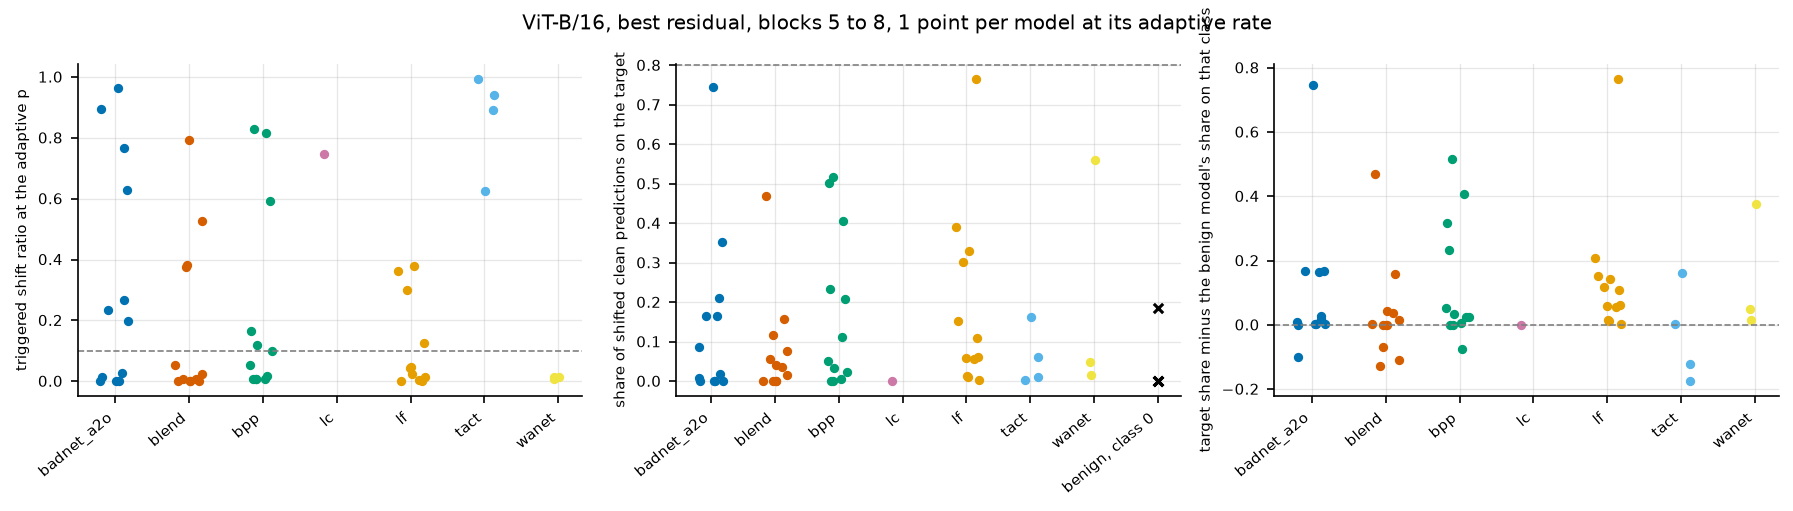

In [23]:
best = rows[(rows["architecture"] == "vit") & (rows["placement"] == BEST_RESIDUAL_PLACEMENT)]
best_attacks = sorted(best.loc[~best["benign"], "attack"].unique())
figure, axes = plt.subplots(1, 3, figsize=(12, 3.4))
for axis, (value, label, threshold) in zip(
    axes,
    (
        ("sigma_backdoor", "triggered shift ratio at the adaptive p", NEAR_ZERO_SHIFT),
        ("validation_target_share", "share of shifted clean predictions on the target", ALMOST_ALL_ON_TARGET),
        ("target_share_over_benign", "target share minus the benign model's share on that class", 0.0),
    ),
):
    for position, attack in enumerate(best_attacks):
        values = best.loc[(best["attack"] == attack) & ~best["benign"], value].dropna()
        jitter = np.random.default_rng(position).uniform(-0.2, 0.2, len(values))
        axis.scatter(position + jitter, values, s=12, color=OKABE_ITO[position % len(OKABE_ITO)])
    if value == "validation_target_share":
        benign_values = best.loc[best["benign"], "validation_target_share"]
        axis.scatter(np.full(len(benign_values), len(best_attacks)), benign_values, marker="x", color="black", s=20)
        axis.set_xticks(range(len(best_attacks) + 1))
        axis.set_xticklabels([*best_attacks, "benign, class 0"], rotation=40, ha="right")
    else:
        axis.set_xticks(range(len(best_attacks)))
        axis.set_xticklabels(best_attacks, rotation=40, ha="right")
    axis.axhline(threshold, color="grey", linestyle="--", linewidth=0.8)
    axis.set_ylabel(label, fontsize=7)
figure.suptitle(f"ViT-B/16, {PLACEMENT_LABELS[BEST_RESIDUAL_PLACEMENT]}, 1 point per model at its adaptive rate")
figure.tight_layout()
plt.show()

In [24]:
best_rows = []
for attack, subset in best[~best["benign"]].groupby("attack"):
    best_rows.append(
        {
            "attack": attack,
            "models": len(subset),
            "claim 1 holds": int((subset["claim_1"] == "holds").sum()),
            "median triggered sigma": subset["sigma_backdoor"].median(),
            "claim 2 holds": int((subset["claim_2"] == "holds").sum()),
            "target leads": int((subset["validation_top_class"] == subset["target_label"]).sum()),
            "median target share": subset["validation_target_share"].median(),
            "median excess over benign": subset["target_share_over_benign"].median(),
            "median PSU ratio AUROC": subset["auroc_psu_ratio"].median(),
        }
    )
best_features = feature_rows[feature_rows["condition"] == "br_adaptive"][
    ["folder", "probe", "rate", "cosine_pair_off", "cosine_pair_shared", "cosine_unrelated_on",
     "cosine_pair_independent", "cosine_unrelated_independent", "clean_toward_triggered_off",
     "clean_toward_triggered_on", "clean_on_target", "triggered_on_target", "claim_3"]
]
display(pd.DataFrame(best_rows).round(3))
best_features.round(3)

,attack,models,claim 1 holds,median triggered sigma,claim 2 holds,target leads,median target share,median excess over benign,median PSU ratio AUROC
0,badnet_a2o,12,5,0.217,0,3,0.052,0.013,0.983
1,blend,12,8,0.015,0,1,0.039,0.001,0.997
2,bpp,12,7,0.077,0,4,0.081,0.029,0.987
3,lc,1,0,0.747,0,0,0.000,0.000,0.667
4,lf,12,8,0.033,0,2,0.085,0.085,0.992
5,tact,4,0,0.917,0,1,0.036,-0.060,0.770
6,wanet,3,3,0.013,0,1,0.050,0.050,0.996


,folder,probe,rate,cosine_pair_off,cosine_pair_shared,cosine_unrelated_on,cosine_pair_independent,cosine_unrelated_independent,clean_toward_triggered_off,clean_toward_triggered_on,clean_on_target,triggered_on_target,claim_3
48,vit_cifar10_badnet_a2o_0_1,badnet_a2o,0.9,0.591,0.973,0.685,0.141,0.074,0.591,0.053,0.361,0.380,fails
52,vit_cifar10_benign,badnet_a2o,0.9,0.975,0.992,0.707,0.192,0.129,0.975,0.157,0.150,0.177,fails
56,vit_cifar10_benign,blend,0.9,0.478,0.812,0.707,0.158,0.129,0.478,0.153,0.150,0.198,fails
60,vit_cifar10_blend_0_1,blend,0.9,0.121,0.637,0.711,0.150,0.122,0.121,0.256,0.126,0.630,fails
64,vit_cifar10_bpp_0_1,bpp,0.9,0.297,0.847,0.682,0.163,0.113,0.297,0.191,0.178,0.487,fails
68,vit_cifar10_lf_0_1,lf,0.9,0.547,0.888,0.695,0.171,0.120,0.547,0.209,0.320,0.720,fails
72,vit_cifar10_tact_0_01,tact,0.9,0.947,0.990,0.742,0.251,0.190,0.947,0.153,0.100,0.102,fails
76,vit_cifar10_tact_0_05,tact,0.8,0.947,0.985,0.648,0.366,0.235,0.947,0.257,0.022,0.061,fails
80,vit_cifar10_wanet_0_1,wanet,0.8,0.901,0.962,0.606,0.275,0.152,0.901,0.249,0.500,0.982,fails
84,vit_gtsrb_badnet_a2o_0_1,badnet_a2o,0.8,0.752,0.976,0.887,0.516,0.481,0.752,0.053,0.701,1.000,fails


**Result.** The placement separates (median PSU ratio AUROC 0.99) and claim 1 is partial on it (31 of 56 models keep the triggered shift ratio at 0.1 or below). Claim 2 holds on none of the 56 (44 fail, 12 partial): the median target share is 0.06, the target leads on 12 models, and the median excess over the benign control is 0.02. A minority does show a target bias: 7 of 56 models send at least 0.3 more of their shifts to the target than the benign control (`vit_cifar100_blend_0_1`, `vit_cifar100_bpp_0_01`, `vit_cifar10_bpp_0_01`, `vit_cifar10_wanet_0_1`, `vit_gtsrb_badnet_a2o_0_1`, `vit_gtsrb_lf_0_1` and `vit_tiny_bpp_0_01`). Claim 3 fails on all 10 poisoned readings. Under a shared mask the pair's cosine rises from 0.67 to 0.97 but an unrelated pair rises to 0.70 from about 0. Under independent masks the pair reads 0.26 against 0.17 for an unrelated pair. The perturbed clean feature moves away from its triggered twin, from 0.67 to 0.19, as it does on the benign models (0.83 to 0.17).

**Verdict: neuron bias does not explain the best residual placement, beyond a target bias on 7 of 56 models.** It separates clean from triggered images without sending clean predictions to the target beyond what a benign model does, and without moving clean features toward the backdoor's. What remains is claim 1 itself: the triggered prediction survives the perturbation more often than the clean one. Why it survives is not isolated here.

## Step 6, the verdicts

1 row per architecture and placement. A claim holds when it holds on at least 2 in 3 of the poisoned models, fails when it fails on at least 2 in 3, and is partial in between (`measure.majority`). The counts behind each verdict and the medians are in the cells, and `summary.json` under `results/_experiments/prediction_shift_phenomenon/` holds every per-model row.

In [25]:
summary_rows = []
for entry in summary["overall"]:
    claim_4_entry = entry["claim_4"]
    summary_rows.append(
        {
            "architecture": ARCHITECTURE_LABELS[entry["architecture"]],
            "placement": PLACEMENT_LABELS[entry["placement"]],
            "poisoned models": entry["models"],
            "claim 1 shift ratio": f"{entry['claim_1']['verdict']} ({entry['claim_1']['counts'].get('holds', 0)} of {entry['claim_1']['total']} hold, median triggered sigma {entry['median_backdoor_sigma']:.2f})",
            "claim 1 benign control": entry["claim_1_benign"]["verdict"] or "no benign model",
            "claim 2 target": f"{entry['claim_2']['verdict']} ({entry['claim_2']['counts'].get('holds', 0)} of {entry['claim_2']['total']} hold, median target share {entry['median_target_share']:.2f})",
            "claim 3 features": (
                f"{entry['claim_3']['verdict']} ({entry['claim_3']['counts'].get('holds', 0)} of {entry['claim_3']['total']} readings hold)"
                if entry["claim_3"]["verdict"]
                else "not measured"
            ),
            "claim 4 std": f"{claim_4_entry['verdict']} (median std AUROC {entry['median_auroc_std_best_rate']:.2f} at its best p, PSU ratio {entry['median_auroc_psu_ratio']:.2f})",
        }
    )
pd.DataFrame(summary_rows)

,architecture,placement,poisoned models,claim 1 shift ratio,claim 1 benign control,claim 2 target,claim 3 features,claim 4 std
0,ResNet-18,PSBD-RD,2,"partial (1 of 2 hold, median triggered sigma 0.13)",no benign model,"partial (0 of 2 hold, median target share 0.33)",fails (1 of 4 readings hold),"BadNets half only (median std AUROC 0.94 at its best p, PSU ratio 0.98)"
1,ViT-B/16,PSBD-RD,56,"partial (26 of 56 hold, median triggered sigma 0.12)",holds,"partial (0 of 56 hold, median target share 0.09)",fails (0 of 20 readings hold),"holds (median std AUROC 0.81 at its best p, PSU ratio 0.98)"
2,ViT-B/16,PSBD-TM,56,"holds (44 of 56 hold, median triggered sigma 0.02)",holds,"fails (4 of 56 hold, median target share 0.02)",fails (0 of 10 readings hold),"partial (median std AUROC 0.94 at its best p, PSU ratio 0.99)"
3,ViT-B/16,"best residual, blocks 5 to 8",56,"partial (31 of 56 hold, median triggered sigma 0.05)",holds,"fails (0 of 56 hold, median target share 0.06)",fails (0 of 10 readings hold),"holds (median std AUROC 0.89 at its best p, PSU ratio 0.99)"
4,Swin-S,PSBD-RD,65,"partial (37 of 65 hold, median triggered sigma 0.01)",holds,"partial (18 of 65 hold, median target share 0.28)",fails (0 of 18 readings hold),"partial (median std AUROC 0.92 at its best p, PSU ratio 0.99)"
5,Swin-S,PSBD-TM,63,"holds (58 of 63 hold, median triggered sigma 0.00)",holds,"partial (29 of 63 hold, median target share 0.68)",fails (0 of 9 readings hold),"holds (median std AUROC 0.97 at its best p, PSU ratio 1.00)"


## What follows for this repository

The detection signal of the paper, clean predictions shifting while triggered ones do not, is visible on all 3 architectures, and PSBD-TM shows it more cleanly on transformers than the paper's own site does. The explanation the paper gives for it does not carry over. Clean shifts land on the target on BadNets, WaNet and Adaptive-Blend Swin models and on the ResNet-18 BadNets models, and elsewhere on a class that a benign model also collapses to. The feature maps become identical only because the 2 images share a mask, and unrelated images do too. The only reading consistent with neuron bias is a partial drift of clean Swin features toward their triggered twins, absent on the benign Swin models. The best residual placement on ViT separates as well without any of it: its clean shifts do not favor the target beyond the benign control and its clean features move away from the triggered ones. `experiments/why_token_masking_works/` gives the isolated account of why PSBD-TM separates patch triggers.